# Classical Benchmark Market Data and CVA Diagnostics

This notebook prepares paper-style figures and LaTeX-ready tables for the **Classical Benchmark** section of a quantitative finance MSc thesis on Quantum CVA.

The notebook is artifact-driven. It recursively inspects the `6q_instance`, discovers the actual two-underlying configuration, loads saved benchmark tensors and curves where present, and only recomputes pathwise exposure quantities when the saved artifacts do not already contain them. No numerical result is fabricated.

## 1. Imports and Paths

The paths below match the project layout used for the `6q_instance`. The bootstrap adds both the repository root and `src` to `sys.path` so existing project functions can be reused directly.

In [1]:
from __future__ import annotations

import importlib
import json
import math
import pickle
import platform
import re
import sys
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path(r"C:\Users\guilb\Desktop\Quantum-CVA")
INSTANCE_DIR = PROJECT_ROOT / r"cva_pricing_pipeline\multi_asset\6q_instance"
MARKET_DATA_DIR = PROJECT_ROOT / r"data\loaded_market_data"
CLASSICAL_SRC_DIR = PROJECT_ROOT / r"src\quantum_cva\multi_asset\classical"

for path in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

FIGURE_DIR = PROJECT_ROOT / r"toys\multi_asset_demos\figures\classical_benchmark"
TABLE_DIR = PROJECT_ROOT / r"toys\multi_asset_demos\tables\classical_benchmark"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
np.set_printoptions(precision=6, suppress=True)

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 320,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#222222",
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.45,
    "grid.alpha": 0.65,
    "lines.linewidth": 1.45,
    "patch.linewidth": 0.5,
})
PALETTE = ["#1f4e79", "#8f3f2f", "#5b6f3a", "#4c4c4c", "#b07d2c"]

saved_figures: list[Path] = []
saved_tables: list[Path] = []

print(f"Project root: {PROJECT_ROOT}")
print(f"Instance directory: {INSTANCE_DIR}")
print(f"Market-data directory: {MARKET_DATA_DIR}")
print(f"Classical source directory: {CLASSICAL_SRC_DIR}")

Project root: C:\Users\guilb\Desktop\Quantum-CVA
Instance directory: C:\Users\guilb\Desktop\Quantum-CVA\cva_pricing_pipeline\multi_asset\6q_instance
Market-data directory: C:\Users\guilb\Desktop\Quantum-CVA\data\loaded_market_data
Classical source directory: C:\Users\guilb\Desktop\Quantum-CVA\src\quantum_cva\multi_asset\classical


## 2. Robust Helper Functions

Discovery is recursive over the instance directory. Data-loading helpers raise explicit errors when a required artifact, key, or column is missing.

In [2]:
RELEVANT_SUFFIXES = {".py", ".json", ".npz", ".csv", ".xlsx", ".xls", ".pkl", ".pickle", ".ipynb"}
RELEVANT_NAME_PATTERNS = re.compile(
    r"(config|benchmark|summary|result|cva|exposure|prob|tensor|discount|default|curve|grid|market|training)",
    re.IGNORECASE,
)

def find_instance_files(instance_dir: Path = INSTANCE_DIR) -> pd.DataFrame:
    if not instance_dir.exists():
        raise FileNotFoundError(f"INSTANCE_DIR does not exist: {instance_dir}")
    rows: list[dict[str, Any]] = []
    for path in sorted(instance_dir.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in RELEVANT_SUFFIXES:
            continue
        rel = path.relative_to(instance_dir)
        if RELEVANT_NAME_PATTERNS.search(path.name) or path.suffix.lower() in {".json", ".npz", ".csv"}:
            rows.append({
                "relative_path": str(rel),
                "suffix": path.suffix.lower(),
                "size_kb": round(path.stat().st_size / 1024.0, 1),
                "modified": pd.Timestamp(path.stat().st_mtime, unit="s"),
            })
    return pd.DataFrame(rows).sort_values(["suffix", "relative_path"]).reset_index(drop=True)

def load_any(path: Path, **kwargs: Any) -> Any:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required artifact is missing: {path}")
    suffix = path.suffix.lower()
    if suffix == ".json":
        return json.loads(path.read_text(encoding="utf-8"))
    if suffix == ".csv":
        return pd.read_csv(path, **kwargs)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path, **kwargs)
    if suffix == ".npz":
        return np.load(path, allow_pickle=True)
    if suffix in {".pkl", ".pickle"}:
        with path.open("rb") as fh:
            return pickle.load(fh)
    if suffix in {".py", ".ipynb", ".txt", ".md"}:
        return path.read_text(encoding="utf-8", errors="replace")
    raise ValueError(f"Unsupported file type for load_any: {path}")

def require_columns(df: pd.DataFrame, columns: Sequence[str], *, where: str) -> None:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns {missing} in {where}. Available columns: {list(df.columns)}")

def scalar_from_npz(npz: Mapping[str, Any], key: str, *, required: bool = True, default: Any = np.nan) -> Any:
    if key not in npz:
        if required:
            raise KeyError(f"Benchmark artifact is missing required key: {key}")
        return default
    value = np.asarray(npz[key])
    return value.item() if value.shape == () else value

def save_figure(fig: mpl.figure.Figure, stem: str) -> list[Path]:
    paths: list[Path] = []
    for ext in ("pdf", "svg", "png"):
        path = FIGURE_DIR / f"{stem}.{ext}"
        fig.savefig(path)
        paths.append(path)
    saved_figures.extend(paths)
    return paths

def save_table(df: pd.DataFrame, stem: str, *, index: bool = False, float_format: str = "%.6g") -> list[Path]:
    paths: list[Path] = []
    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"
    df.to_csv(csv_path, index=index)
    tex_path.write_text(df.to_latex(index=index, escape=False, float_format=float_format), encoding="utf-8")
    paths.extend([csv_path, tex_path])
    try:
        xlsx_path = TABLE_DIR / f"{stem}.xlsx"
        df.to_excel(xlsx_path, index=index)
        paths.append(xlsx_path)
    except Exception as exc:
        print(f"[info] Excel export skipped for {stem}: {exc}")
    saved_tables.extend(paths)
    return paths

def normalise_prices(prices: pd.DataFrame, underlyings: Sequence[str]) -> pd.DataFrame:
    require_columns(prices, ["date", *underlyings], where="market_data.prices")
    out = prices[["date", *underlyings]].copy().sort_values("date")
    for asset in underlyings:
        series = pd.to_numeric(out[asset], errors="coerce")
        out[asset] = series / series.dropna().iloc[0]
    return out.dropna(subset=list(underlyings), how="all")

def compute_log_return_correlation(prices: pd.DataFrame, underlyings: Sequence[str]) -> pd.DataFrame:
    require_columns(prices, ["date", *underlyings], where="market_data.prices")
    returns = np.log(prices[list(underlyings)] / prices[list(underlyings)].shift(1)).dropna(how="any")
    return returns.corr()

def compute_default_increments(survival: Sequence[float]) -> np.ndarray:
    survival_arr = np.asarray(survival, dtype=float).reshape(-1)
    return np.r_[1.0, survival_arr[:-1]] - survival_arr

def compute_ee_with_ci(vpos: np.ndarray) -> pd.DataFrame:
    arr = np.asarray(vpos, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected pathwise positive exposure matrix with shape (N_paths, M); got {arr.shape}")
    n_paths = arr.shape[0]
    if n_paths < 2:
        raise ValueError("At least two Monte Carlo paths are required for standard errors.")
    ee = arr.mean(axis=0)
    se = arr.std(axis=0, ddof=1) / math.sqrt(n_paths)
    return pd.DataFrame({
        "EE": ee,
        "EE_standard_error": se,
        "EE_lower_95_CI": ee - 1.96 * se,
        "EE_upper_95_CI": ee + 1.96 * se,
    })

def compute_cva_contributions(
    ee: Sequence[float],
    discount_factors: Sequence[float],
    default_increments: Sequence[float],
    recovery_rate: float,
) -> pd.DataFrame:
    ee_arr = np.asarray(ee, dtype=float).reshape(-1)
    p_arr = np.asarray(discount_factors, dtype=float).reshape(-1)
    q_arr = np.asarray(default_increments, dtype=float).reshape(-1)
    if not (ee_arr.shape == p_arr.shape == q_arr.shape):
        raise ValueError(f"Shapes must align: EE={ee_arr.shape}, D={p_arr.shape}, dq={q_arr.shape}")
    period = (1.0 - float(recovery_rate)) * p_arr * q_arr * ee_arr
    cumulative = np.cumsum(period)
    total = float(period.sum())
    pct = np.where(total != 0.0, period / total * 100.0, np.nan)
    return pd.DataFrame({
        "period_CVA_contribution": period,
        "cumulative_CVA_contribution": cumulative,
        "percentage_of_total_CVA": pct,
    })

def years_to_dates(valuation_date: str | pd.Timestamp | None, t: Sequence[float]) -> list[Any]:
    if valuation_date is None or pd.isna(valuation_date):
        return [np.nan] * len(t)
    vdate = pd.Timestamp(valuation_date)
    return [(vdate + pd.to_timedelta(float(x) * 365.0, unit="D")).date().isoformat() for x in t]

def resolve_project_path(path_like: str | Path) -> Path:
    path = Path(path_like)
    return path if path.is_absolute() else PROJECT_ROOT / path

def rel_to_project(path: Path) -> str:
    try:
        return str(Path(path).resolve().relative_to(PROJECT_ROOT.resolve()))
    except Exception:
        return str(path)

## 3. Automatic Discovery of the 6q Instance Configuration

This section inventories the instance directory and searches JSON/NPZ artifacts for the selected underlyings, counterparty inputs, benchmark CVA outputs, curves, tensors, and grid-convergence data.

In [3]:
inventory = find_instance_files(INSTANCE_DIR)
print(f"Discovered {len(inventory)} relevant files under INSTANCE_DIR.")
display(inventory.head(40))
artifact_summary = inventory.groupby("suffix").agg(files=("relative_path", "count"), total_size_kb=("size_kb", "sum")).reset_index()
display(artifact_summary.sort_values("suffix"))

Discovered 544 relevant files under INSTANCE_DIR.


,relative_path,suffix,size_kb,modified
0,cva_pricing_multi_asset\quantum\ae_cva\grover_...,.csv,11.8,2026-05-06 18:26:01.480531931
1,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,4.3,2026-05-12 12:08:58.953079224
2,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,1.5,2026-05-12 12:08:58.953079224
3,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,8.0,2026-05-12 12:08:59.505014180
4,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.0,2026-05-12 12:08:58.953079224
5,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.0,2026-05-12 12:08:58.953079224
6,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.0,2026-05-12 12:08:58.948311567
7,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.3,2026-05-12 12:09:06.317660093
8,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.3,2026-05-12 12:09:07.002975225
9,cva_pricing_multi_asset\quantum\ae_cva\hardwar...,.csv,0.3,2026-05-12 12:08:58.948311567


,suffix,files,total_size_kb
0,.csv,157,81642.2
1,.json,202,658.4
2,.npz,155,95309.4
3,.py,30,611.2


In [4]:
def config_score(path: Path, payload: Mapping[str, Any]) -> tuple[int, int, float]:
    rel = str(path.relative_to(INSTANCE_DIR)).replace("\\", "/")
    score = 0
    if "assets" in payload and "market_data" in payload:
        score += 20
    if "classical" in payload and "quantum" in payload:
        score += 10
    if "/base/" in f"/{rel}/":
        score += 8
    if "pipeline_run" in rel:
        score += 5
    if payload.get("paths", {}).get("instance_name") == "6q_instance":
        score += 5
    return (score, -len(rel), path.stat().st_mtime)

config_candidates: list[tuple[Path, dict[str, Any]]] = []
for rel in inventory.loc[inventory["suffix"].eq(".json"), "relative_path"]:
    path = INSTANCE_DIR / rel
    try:
        payload = load_any(path)
    except Exception:
        continue
    if isinstance(payload, dict) and "assets" in payload and "market_data" in payload:
        config_candidates.append((path, payload))

if config_candidates:
    CONFIG_PATH, CONFIG = sorted(config_candidates, key=lambda item: config_score(item[0], item[1]), reverse=True)[0]
else:
    full_pipeline = INSTANCE_DIR / "full_cva_pipeline.py"
    if not full_pipeline.exists():
        raise RuntimeError("Could not discover a config JSON or full_cva_pipeline.py with CONFIG.")
    spec = importlib.util.spec_from_file_location("sixq_full_cva_pipeline", full_pipeline)
    module = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(module)
    from dataclasses import asdict, is_dataclass
    CONFIG = asdict(module.CONFIG) if is_dataclass(module.CONFIG) else module.CONFIG
    CONFIG_PATH = full_pipeline

print("Selected configuration:", rel_to_project(CONFIG_PATH))
print(json.dumps({
    "assets": CONFIG.get("assets"),
    "market_data": CONFIG.get("market_data"),
    "classical": CONFIG.get("classical"),
    "quantum": CONFIG.get("quantum"),
    "paths": CONFIG.get("paths"),
}, indent=2)[:3000])

assets_cfg = CONFIG.get("assets")
if not isinstance(assets_cfg, list) or len(assets_cfg) == 0:
    raise ValueError(f"Configuration {CONFIG_PATH} does not contain a non-empty assets list.")
underlyings = [str(asset["symbol"]) for asset in assets_cfg]
if len(underlyings) != 2:
    raise ValueError(f"The selected 6q instance is expected to use 2 underlyings, but discovery found {len(underlyings)}: {underlyings}.")

dividend_yields = {str(asset["symbol"]): float(asset.get("dividend_yield", np.nan)) for asset in assets_cfg}
classical_cfg = CONFIG.get("classical", {})
quantum_cfg = CONFIG.get("quantum", {})
market_cfg = CONFIG.get("market_data", {})
paths_cfg = CONFIG.get("paths", {})
valuation_date = market_cfg.get("valuation_date")
credit_path = resolve_project_path(market_cfg.get("credit_data_path", MARKET_DATA_DIR / "iberdrola_data.xlsx"))
counterparty = credit_path.stem.replace("_data", "").title()
print(f"Discovered underlyings: {underlyings}")
print(f"Discovered counterparty/credit file: {counterparty} ({rel_to_project(credit_path)})")

Selected configuration: cva_pricing_pipeline\multi_asset\6q_instance\cva_robustness_test\base\pipeline_run\pipeline_config.json
{
  "assets": [
    {
      "dividend_yield": 0.0224722,
      "symbol": ".STOXX50E"
    },
    {
      "dividend_yield": 0.0316306,
      "symbol": ".SSMI"
    }
  ],
  "market_data": {
    "atm_vol_surfaces_path": "data/loaded_market_data/vol_surfaces.xlsx",
    "credit_data_path": "data/loaded_market_data/iberdrola_data.xlsx",
    "discount_curve_path": "data/loaded_market_data/discount_curve.xlsx",
    "flat_interest_rate_override": null,
    "historical_series_path": "data/loaded_market_data/time_series.xlsx",
    "valuation_date": "2026-03-15"
  },
  "classical": {
    "antithetic": true,
    "cds_pay_freq": 4,
    "fine_time_grid_size": 50,
    "flattening_order": "time_major",
    "grid_convergence_max_bits": 6,
    "grid_convergence_min_bits": 1,
    "grid_limit_bits": 8,
    "m_time": 2,
    "moment_match": true,
    "n_paths": 100000,
    "n_sigma":

In [5]:
primary_benchmark_path = PROJECT_ROOT / "data" / "multi_asset" / "6q_instance" / "benchmark" / "three_asset_instance.npz"
if not primary_benchmark_path.exists():
    raise FileNotFoundError(f"Required benchmark NPZ artifact was not found: {primary_benchmark_path}")

BENCHMARK_PATH = primary_benchmark_path
benchmark = np.load(BENCHMARK_PATH, allow_pickle=True)
BENCHMARK_KEYS = set(benchmark.files)
print(f"Selected benchmark: {rel_to_project(BENCHMARK_PATH)}")
print(f"Benchmark grid sizes: {np.asarray(benchmark['grid_sizes'], dtype=int).reshape(-1).tolist()}")

Selected benchmark: data\multi_asset\6q_instance\benchmark\three_asset_instance.npz
Benchmark grid sizes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 4. Market Data Loading

The project `MarketData` class loads the same prices, ATM volatility term structures, discount curve, CDS spreads, and recovery-rate inputs used by the classical benchmark pipeline.

In [6]:
try:
    from quantum_cva.multi_asset.instruments.market_data import MarketData
except Exception as exc:
    raise ImportError("Could not import MarketData. Ensure PROJECT_ROOT/src is importable.") from exc

required_market_keys = ["discount_curve_path", "credit_data_path", "historical_series_path", "atm_vol_surfaces_path"]
missing_market_keys = [key for key in required_market_keys if key not in market_cfg]
if missing_market_keys:
    raise KeyError(f"Selected config is missing market_data keys: {missing_market_keys}")

market_paths = {key: resolve_project_path(market_cfg[key]) for key in required_market_keys}
for key, path in market_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Market-data file for {key} is missing: {path}")

market_data = MarketData.load(
    discount_curve_path=market_paths["discount_curve_path"],
    credit_data_path=market_paths["credit_data_path"],
    historical_series_path=market_paths["historical_series_path"],
    atm_vol_surfaces_path=market_paths["atm_vol_surfaces_path"],
    valuation_date=valuation_date,
)

for asset in underlyings:
    if asset not in market_data.prices.columns:
        raise ValueError(f"Selected underlying {asset!r} is not present in historical prices. Available: {[c for c in market_data.prices.columns if c != 'date']}")
    if asset not in set(market_data.atm_vols["underlying"]):
        raise ValueError(f"Selected underlying {asset!r} is not present in ATM vol surfaces. Available: {sorted(market_data.atm_vols['underlying'].unique())}")

print("Loaded market data with selected underlyings only:")
print("Prices:", market_data.prices[["date", *underlyings]].shape)
print("Log returns:", market_data.log_returns[["date", *underlyings]].shape)
print("ATM vol rows:", market_data.get_atm_vol_curves(underlyings=underlyings).shape)
print("Discount curve rows:", market_data.discount_curve.shape)
print("CDS rows:", market_data.credit_spreads.shape)
print("CDS recovery rate:", market_data.recovery_rate)

Loaded market data with selected underlyings only:
Prices: (1299, 3)
Log returns: (1299, 3)
ATM vol rows: (53, 4)
Discount curve rows: (36, 3)
CDS rows: (10, 2)
CDS recovery rate: 0.4


## 5. Existing Project-Function Discovery and Reuse

The notebook reuses project functions for survival bootstrapping, piecewise volatility, risk-neutral path generation, instrument pricing, and continuous CVA aggregation.

In [7]:
try:
    from quantum_cva.multi_asset.classical.classical_cva.cva_auxiliar_functions import build_survival_from_cds
    from quantum_cva.multi_asset.classical.classical_cva.classical_cont_cva import ContinuousUnderlyingCvaEngine
    from quantum_cva.multi_asset.classical.classical_cva.classical_discrete_cva import DiscreteUnderlyingCvaEngine
    from quantum_cva.multi_asset.classical.probability_and_underlying.multi_asset_dynamics_utils import simulate_multi_asset_gbm
    from quantum_cva.multi_asset.classical.probability_and_underlying.piecewise_volatility_utils import build_piecewise_sigma_grid, build_residual_volatility_function_for_underlying
    from quantum_cva.multi_asset.instruments.derivatives import Call, Forward, Put
except Exception as exc:
    raise ImportError(f"Could not import required project functions from {CLASSICAL_SRC_DIR}.") from exc

project_functions = [
    "build_survival_from_cds", "ContinuousUnderlyingCvaEngine", "DiscreteUnderlyingCvaEngine",
    "simulate_multi_asset_gbm", "build_piecewise_sigma_grid", "build_residual_volatility_function_for_underlying",
    "Call", "Put", "Forward",
]
usage_rows = []
for rel in inventory.loc[inventory["suffix"].eq(".py"), "relative_path"]:
    path = INSTANCE_DIR / rel
    text = path.read_text(encoding="utf-8", errors="replace")
    hits = [name for name in project_functions if name in text]
    if hits:
        usage_rows.append({"script": str(rel), "project_functions_used": ", ".join(hits)})
print("Imported project functions:", ", ".join(project_functions))
display(pd.DataFrame(usage_rows).head(30))

Imported project functions: build_survival_from_cds, ContinuousUnderlyingCvaEngine, DiscreteUnderlyingCvaEngine, simulate_multi_asset_gbm, build_piecewise_sigma_grid, build_residual_volatility_function_for_underlying, Call, Put, Forward


,script,project_functions_used
0,cva_pricing_multi_asset\classical\plot_small_i...,simulate_multi_asset_gbm
1,cva_pricing_multi_asset\classical\run_classica...,"build_survival_from_cds, ContinuousUnderlyingC..."
2,cva_pricing_multi_asset\quantum\ae_cva\noisele...,Forward
3,cva_pricing_multi_asset\quantum\ae_cva\noisy_s...,Forward


## 6. Data Validation and Derived Benchmark Quantities

These checks verify two-underlying semantics, monitoring-date alignment, probability normalization, and tensor dimensions before generating results.

In [8]:
required_benchmark_keys = [
    "t", "p_t", "q_t", "P_joint_t", "v_joint_t", "grid_sizes", "cva_by_grid_size_values",
    "cva_mc_continuous", "cva_std_err_mc_continuous", "S0", "rho", "R_cva", "LGD", "n_bits_small",
]
missing_keys = [key for key in required_benchmark_keys if key not in benchmark.files]
if missing_keys:
    raise KeyError(f"Benchmark artifact {BENCHMARK_PATH} is missing required keys: {missing_keys}")

t = np.asarray(benchmark["t"], dtype=float).reshape(-1)
p_t = np.asarray(benchmark["p_t"], dtype=float).reshape(-1)
q_t = np.asarray(benchmark["q_t"], dtype=float).reshape(-1)
P_joint_t = np.asarray(benchmark["P_joint_t"], dtype=float)
v_joint_t = np.asarray(benchmark["v_joint_t"], dtype=float)
survival_grid = np.asarray(benchmark["survival_on_exposure_grid"], dtype=float).reshape(-1) if "survival_on_exposure_grid" in benchmark.files else 1.0 - np.cumsum(q_t)

if not (t.shape == p_t.shape == q_t.shape == survival_grid.shape):
    raise ValueError(f"Monitoring arrays must align. t={t.shape}, p_t={p_t.shape}, q_t={q_t.shape}, survival={survival_grid.shape}")
if P_joint_t.shape != v_joint_t.shape or P_joint_t.shape[0] != t.size:
    raise ValueError(f"P_joint_t and v_joint_t must align with t. P={P_joint_t.shape}, V={v_joint_t.shape}, t={t.shape}")
if not np.allclose(P_joint_t.sum(axis=1), 1.0, atol=2e-10):
    raise ValueError("Each P_joint_t row must sum to one.")

S0 = np.asarray(benchmark["S0"], dtype=float).reshape(-1)
rho_benchmark = np.asarray(benchmark["rho"], dtype=float)
n_bits_small = np.asarray(benchmark["n_bits_small"], dtype=int).reshape(-1)
if S0.size != len(underlyings) or rho_benchmark.shape != (len(underlyings), len(underlyings)) or n_bits_small.size != len(underlyings):
    raise ValueError("Benchmark dimensions do not match discovered two-underlying configuration.")

recovery_rate = float(scalar_from_npz(benchmark, "R_cva"))
lgd = float(scalar_from_npz(benchmark, "LGD"))
m_time = int(classical_cfg.get("m_time", round(math.log2(t.size))))
time_qubits = m_time
asset_qubits = int(np.sum(n_bits_small))
total_grid_cells = int(np.asarray(benchmark["N_joint"]).item()) if "N_joint" in benchmark.files else int(np.prod(2 ** n_bits_small))
monitoring_dates = years_to_dates(valuation_date, t)

ee_tabulated = (P_joint_t * v_joint_t).sum(axis=1)
cva_tab_contrib = compute_cva_contributions(ee_tabulated, p_t, q_t, recovery_rate)

print("Validation passed.")
print(f"Monitoring times: {t}")
print(f"Tabulated EE from P_joint_t and v_joint_t: {ee_tabulated}")
print(f"Tabulated finite-grid CVA from decomposition: {cva_tab_contrib['period_CVA_contribution'].sum():.12g}")
print(f"Continuous MC CVA: {float(benchmark['cva_mc_continuous']):.12g} ± {float(benchmark['cva_std_err_mc_continuous']):.3g}")

Validation passed.
Monitoring times: [0.125 0.25  0.375 0.5  ]
Tabulated EE from P_joint_t and v_joint_t: [2261.227546 2282.240849    0.          0.      ]
Tabulated finite-grid CVA from decomposition: 0.521833977137
Continuous MC CVA: 1.09053494237 ± 0.00098


## 7. Continuous Expected Exposure Reconstruction

The benchmark stores finite-grid exposure tensors and continuous MC CVA. If it does not store a pathwise positive exposure matrix, this cell reconstructs the calibrated two-asset risk-neutral simulation with the project functions to obtain EE confidence intervals.

In [9]:
def extract_pathwise_vpos_from_artifacts(benchmark_npz: Mapping[str, Any]) -> np.ndarray | None:
    for key in ["Vpos", "V_pos", "positive_exposure", "positive_exposures", "pathwise_exposure", "pathwise_exposures"]:
        if key in benchmark_npz:
            arr = np.asarray(benchmark_npz[key], dtype=float)
            if arr.ndim == 2 and arr.shape[1] == t.size:
                return arr
    return None

def build_continuous_engine_and_paths() -> tuple[ContinuousUnderlyingCvaEngine, np.ndarray]:
    flat_override = market_cfg.get("flat_interest_rate_override")
    if flat_override is None:
        p0_func = lambda u: market_data.discount_factor(float(u))
        r = float(-np.log(p0_func(1.0)))
    else:
        r = float(flat_override)
        p0_func = lambda u, r=r: float(np.exp(-r * float(u)))

    cds_tenors_years, cds_spreads = market_data.get_cds_curve()
    _, _, _, q_interval = build_survival_from_cds(
        P0=p0_func,
        tenors=cds_tenors_years,
        spreads=cds_spreads,
        R_cds=float(market_data.recovery_rate),
        pay_freq=int(classical_cfg.get("cds_pay_freq", 4)),
    )
    atm_vol_curves = market_data.get_atm_vol_curves(underlyings=underlyings)
    sigma_grid = build_piecewise_sigma_grid(atm_vol_curves=atm_vol_curves, underlyings=underlyings, sim_times=t)
    s0_list = market_data.get_spot_vector(underlyings)
    rho = market_data.get_log_return_correlation(underlyings)
    mu_list = [r - dividend_yields[symbol] for symbol in underlyings]
    n_paths = int(classical_cfg.get("n_paths", 100_000))
    rng = np.random.default_rng(int(classical_cfg.get("seed", 105)))
    z = rng.standard_normal(size=(n_paths, t.size, len(underlyings)))
    s_by_time = simulate_multi_asset_gbm(
        S0=s0_list,
        mu=mu_list,
        sigma=sigma_grid,
        rho=rho,
        t=t,
        Z=z,
        antithetic=bool(classical_cfg.get("antithetic", True)),
        moment_match=bool(classical_cfg.get("moment_match", True)),
        replications=int(classical_cfg.get("replications", 1)),
        replication_seed=int(classical_cfg.get("replication_seed", 12345)),
        pathwise=True,
    )

    sigma_funcs = {symbol: build_residual_volatility_function_for_underlying(atm_vol_curves=atm_vol_curves, underlying=symbol) for symbol in underlyings}
    asset_index = {symbol: idx for idx, symbol in enumerate(underlyings)}
    instruments = []
    for inst_cfg in CONFIG.get("instruments", []):
        symbol = inst_cfg["asset_symbol"]
        if symbol not in asset_index:
            raise ValueError(f"Instrument references asset {symbol!r}, not among discovered underlyings {underlyings}")
        common = dict(
            asset_idx=asset_index[symbol],
            quantity=float(inst_cfg["quantity"]),
            multiplier=float(inst_cfg["multiplier"]),
            K=float(inst_cfg["strike"]),
            T=float(inst_cfg["maturity_years"]),
        )
        kind = str(inst_cfg["kind"]).lower()
        if kind == "call":
            instruments.append(Call(**common, sigma_func=sigma_funcs[symbol]))
        elif kind == "put":
            instruments.append(Put(**common, sigma_func=sigma_funcs[symbol]))
        elif kind == "forward":
            instruments.append(Forward(**common))
        else:
            raise ValueError(f"Unsupported instrument kind in config: {kind}")

    engine = ContinuousUnderlyingCvaEngine(instruments=instruments, P0_func=p0_func, q_interval=q_interval, LGD=1.0 - recovery_rate, r=r)
    return engine, s_by_time

Vpos_paths = extract_pathwise_vpos_from_artifacts(benchmark)
pathwise_source = "saved benchmark artifact"
if Vpos_paths is None:
    pathwise_source = "recomputed with project classical pipeline functions"
    continuous_engine, S_by_time = build_continuous_engine_and_paths()
    Vpos_paths = continuous_engine.positive_exposure_matrix(S_by_time=S_by_time, t=t)
    cva_check, cva_check_se = continuous_engine.cva_from_paths(S_by_time=S_by_time, t=t)
    print(f"Recomputed continuous MC CVA check: {cva_check:.12g} ± {cva_check_se:.3g}")
    print(f"Saved continuous MC CVA:          {float(benchmark['cva_mc_continuous']):.12g} ± {float(benchmark['cva_std_err_mc_continuous']):.3g}")
    if not np.isclose(cva_check, float(benchmark["cva_mc_continuous"]), rtol=5e-3, atol=5e-4):
        print("[warning] Recomputed CVA differs from saved CVA beyond tolerance. EE CI uses recomputed pathwise exposures; benchmark CVA remains the saved reference.")

exposure_ci = compute_ee_with_ci(Vpos_paths)
pathwise_discounted_losses = lgd * (Vpos_paths @ (p_t * q_t))
print(f"Pathwise exposure source: {pathwise_source}")
print(f"Positive exposure matrix shape: {Vpos_paths.shape}")
display(exposure_ci)

Recomputed continuous MC CVA check: 1.09053494237 ± 0.00098
Saved continuous MC CVA:          1.09053494237 ± 0.00098
Pathwise exposure source: recomputed with project classical pipeline functions
Positive exposure matrix shape: (200000, 4)


,EE,EE_standard_error,EE_lower_95_CI,EE_upper_95_CI
0,4765.896982,3.906463,4758.240315,4773.553649
1,4728.987710,5.254859,4718.688186,4739.287234
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000


## 8. Summary Tables

Each table is exported to `tables/classical_benchmark/` as `.tex`, `.csv`, and `.xlsx` when the Excel engine is available.

In [10]:
continuous_cva = float(benchmark["cva_mc_continuous"])
continuous_cva_se = float(benchmark["cva_std_err_mc_continuous"])
cva_limit = float(benchmark["cva_limit"])
finite_grid_cva = float(scalar_from_npz(benchmark, "cva_small", required=False, default=np.nan))
if not np.isfinite(finite_grid_cva):
    reference_bits = int(CONFIG.get("final_cva", {}).get("classical_reference_grid_bits", n_bits_small[0]))
    grid_sizes_tmp = np.asarray(benchmark["grid_sizes"], dtype=int).reshape(-1)
    cva_values_tmp = np.asarray(benchmark["cva_by_grid_size_values"], dtype=float).reshape(-1)
    match = np.flatnonzero(grid_sizes_tmp == reference_bits)
    finite_grid_cva = float(cva_values_tmp[int(match[0])]) if match.size else np.nan

instance_summary = pd.DataFrame([
    ("instance name", paths_cfg.get("instance_name", "6q_instance")),
    ("number of underlyings", len(underlyings)),
    ("names/tickers of selected underlyings", ", ".join(underlyings)),
    ("counterparty", counterparty),
    ("valuation date", valuation_date),
    ("number of monitoring dates", len(t)),
    ("recovery rate", recovery_rate),
    ("number of Monte Carlo paths", int(classical_cfg.get("n_paths", Vpos_paths.shape[0]))),
    ("number of time qubits", time_qubits),
    ("number of asset qubits", asset_qubits),
    ("total grid cells", total_grid_cells),
    ("continuous MC CVA", continuous_cva),
    ("continuous MC CVA standard error", continuous_cva_se),
    ("limit CVA", cva_limit),
    ("finite-grid tabulated CVA", finite_grid_cva),
], columns=["item", "value"])
save_table(instance_summary, "table_1_instance_summary")
display(instance_summary)

,item,value
0,instance name,6q_instance
1,number of underlyings,2
2,names/tickers of selected underlyings,".STOXX50E, .SSMI"
3,counterparty,Iberdrola
4,valuation date,2026-03-15
5,number of monitoring dates,4
6,recovery rate,0.415
7,number of Monte Carlo paths,100000
8,number of time qubits,2
9,number of asset qubits,4


In [11]:
prices_selected = market_data.prices[["date", *underlyings]].copy()
returns_selected = market_data.log_returns[["date", *underlyings]].copy()
atm_curves = market_data.get_atm_vol_curves(underlyings=underlyings)
sigma_grid = np.asarray(benchmark["sigma"], dtype=float) if "sigma" in benchmark.files else np.full((len(t), len(underlyings)), np.nan)

market_rows = []
for j, asset in enumerate(underlyings):
    valid_mask = pd.to_numeric(prices_selected[asset], errors="coerce").notna()
    price_series = pd.to_numeric(prices_selected.loc[valid_mask, asset], errors="coerce")
    ret_series = pd.to_numeric(returns_selected[asset], errors="coerce").dropna()
    calibrated_atm = float(np.nanmean(sigma_grid[:, j])) if sigma_grid.ndim == 2 and sigma_grid.shape[1] > j else np.nan
    market_rows.append({
        "underlying": asset,
        "initial spot": float(S0[j]) if j < S0.size else float(price_series.iloc[-1]),
        "dividend yield": dividend_yields.get(asset, np.nan),
        "calibrated / ATM volatility": calibrated_atm,
        "historical annualized volatility": float(ret_series.std(ddof=1) * np.sqrt(252.0)),
        "average return": float(ret_series.mean() * 252.0),
        "number of observations": int(price_series.shape[0]),
        "date range": f"{prices_selected.loc[valid_mask, 'date'].min().date()} to {prices_selected.loc[valid_mask, 'date'].max().date()}",
    })
market_input_summary = pd.DataFrame(market_rows)
save_table(market_input_summary, "table_2_market_input_summary")
display(market_input_summary)

,underlying,initial spot,dividend yield,calibrated / ATM volatility,historical annualized volatility,average return,number of observations,date range
0,.STOXX50E,5716.610000,0.022472,0.191750,0.169202,0.074817,1285,2021-03-15 to 2026-03-13
1,.SSMI,14214.720613,0.031631,0.155527,0.135819,0.068801,1258,2021-03-15 to 2026-03-13


In [12]:
correlation_matrix = compute_log_return_correlation(market_data.prices, underlyings)
save_table(correlation_matrix.reset_index().rename(columns={"index": "underlying"}), "table_3_correlation_matrix")
display(correlation_matrix)

,.STOXX50E,.SSMI
.STOXX50E,1.000000,0.688145
.SSMI,0.688145,1.000000


In [13]:
curve_summary = pd.DataFrame({
    "maturity / date": [f"{ti:.3f} / {di}" for ti, di in zip(t, monitoring_dates)],
    "discount factor D(0,t)": p_t,
    "survival probability P(0,t)": survival_grid,
    "default increment Δq(t)": q_t,
    "cumulative default probability 1−P(0,t)": 1.0 - survival_grid,
})
save_table(curve_summary, "table_4_discount_credit_curve_summary")
display(curve_summary)

,maturity / date,"discount factor D(0,t)","survival probability P(0,t)",default increment Δq(t),"cumulative default probability 1−P(0,t)"
0,0.125 / 2026-04-29,0.997528,0.999803,0.000197,0.000197
1,0.250 / 2026-06-14,0.995003,0.999606,0.000197,0.000394
2,0.375 / 2026-07-29,0.992311,0.999409,0.000197,0.000591
3,0.500 / 2026-09-13,0.989540,0.999212,0.000197,0.000788


In [14]:
exposure_decomp = pd.concat([
    pd.DataFrame({"maturity": t, "date": monitoring_dates}),
    exposure_ci.rename(columns={
        "EE": "EE(0,t_i)",
        "EE_standard_error": "standard error of EE",
        "EE_lower_95_CI": "lower 95% CI",
        "EE_upper_95_CI": "upper 95% CI",
    }),
    pd.DataFrame({"discount factor": p_t, "default increment": q_t}),
], axis=1)
exposure_decomp = pd.concat([exposure_decomp, compute_cva_contributions(exposure_decomp["EE(0,t_i)"], p_t, q_t, recovery_rate)], axis=1)
exposure_decomp = exposure_decomp.rename(columns={
    "period_CVA_contribution": "period CVA contribution",
    "cumulative_CVA_contribution": "cumulative CVA contribution",
    "percentage_of_total_CVA": "percentage of total CVA",
})
save_table(exposure_decomp, "table_5_exposure_cva_decomposition")
display(exposure_decomp)

,maturity,date,"EE(0,t_i)",standard error of EE,lower 95% CI,upper 95% CI,discount factor,default increment,period CVA contribution,cumulative CVA contribution,percentage of total CVA
0,0.125,2026-04-29,4765.896982,3.906463,4758.240315,4773.553649,0.997528,0.000197,0.548132,0.548132,50.26265
1,0.250,2026-06-14,4728.987710,5.254859,4718.688186,4739.287234,0.995003,0.000197,0.542403,1.090535,49.73735
2,0.375,2026-07-29,0.000000,0.000000,0.000000,0.000000,0.992311,0.000197,0.000000,1.090535,0.00000
3,0.500,2026-09-13,0.000000,0.000000,0.000000,0.000000,0.989540,0.000197,0.000000,1.090535,0.00000


In [15]:
grid_bits = np.asarray(benchmark["grid_sizes"], dtype=int).reshape(-1)
grid_cva = np.asarray(benchmark["cva_by_grid_size_values"], dtype=float).reshape(-1)
cva_limit = float(benchmark["cva_limit"])
if grid_bits.shape != grid_cva.shape:
    raise ValueError(f"grid_sizes and cva_by_grid_size_values must align. Got {grid_bits.shape} and {grid_cva.shape}")
max_asset_grid_qubits_per_underlying = 10
plot_mask = grid_bits <= max_asset_grid_qubits_per_underlying
grid_bits = grid_bits[plot_mask]
grid_cva = grid_cva[plot_mask]
if not np.any(grid_bits == max_asset_grid_qubits_per_underlying):
    raise ValueError(f"Benchmark grid_sizes must include n={max_asset_grid_qubits_per_underlying} to build Figure 5.")

conv_rows = []
for bits, cva in zip(grid_bits, grid_cva):
    per_asset_bits = int(bits)
    asset_bits_i = int(per_asset_bits * len(underlyings))
    total_qubits_i = int(time_qubits + asset_bits_i)
    grid_size_i = int((2 ** per_asset_bits) ** len(underlyings))
    abs_error = float(abs(float(cva) - cva_limit))
    rel_error = float(abs_error / abs(cva_limit)) if cva_limit != 0.0 else np.nan
    conv_rows.append({
        "time qubits": time_qubits,
        "asset qubits per underlying": per_asset_bits,
        "asset qubits": asset_bits_i,
        "total qubits": total_qubits_i,
        "grid size": grid_size_i,
        "CVA^tab_Δ": float(cva),
        "CVA^limit": cva_limit,
        "absolute error": abs_error,
        "relative error": rel_error,
        "MC standard error / confidence interval": f"{continuous_cva_se:.6g}; 95% CI ± {1.96 * continuous_cva_se:.6g}",
    })
finite_grid_convergence = pd.DataFrame(conv_rows)
save_table(finite_grid_convergence, "table_6_finite_grid_convergence")
display(finite_grid_convergence)

,time qubits,asset qubits per underlying,asset qubits,total qubits,grid size,CVA^tab_Δ,CVA^limit,absolute error,relative error,MC standard error / confidence interval
0,2,1,2,4,4,0.403616,1.089942,0.686326,0.629691,0.000980329; 95% CI ± 0.00192145
1,2,2,4,6,16,0.521590,1.089942,0.568352,0.521452,0.000980329; 95% CI ± 0.00192145
2,2,3,6,8,64,0.796786,1.089942,0.293156,0.268965,0.000980329; 95% CI ± 0.00192145
3,2,4,8,10,256,0.943338,1.089942,0.146604,0.134506,0.000980329; 95% CI ± 0.00192145
4,2,5,10,12,1024,1.017008,1.089942,0.072934,0.066915,0.000980329; 95% CI ± 0.00192145
5,2,6,12,14,4096,1.053741,1.089942,0.036201,0.033214,0.000980329; 95% CI ± 0.00192145
6,2,7,14,16,16384,1.072029,1.089942,0.017913,0.016435,0.000980329; 95% CI ± 0.00192145
7,2,8,16,18,65536,1.081125,1.089942,0.008817,0.008089,0.000980329; 95% CI ± 0.00192145
8,2,9,18,20,262144,1.085675,1.089942,0.004267,0.003915,0.000980329; 95% CI ± 0.00192145
9,2,10,20,22,1048576,1.087952,1.089942,0.001990,0.001826,0.000980329; 95% CI ± 0.00192145


## 9. Main Paper-Style Figures

All figures are saved as `.pdf`, `.svg`, and `.png` in `figures/classical_benchmark/`.

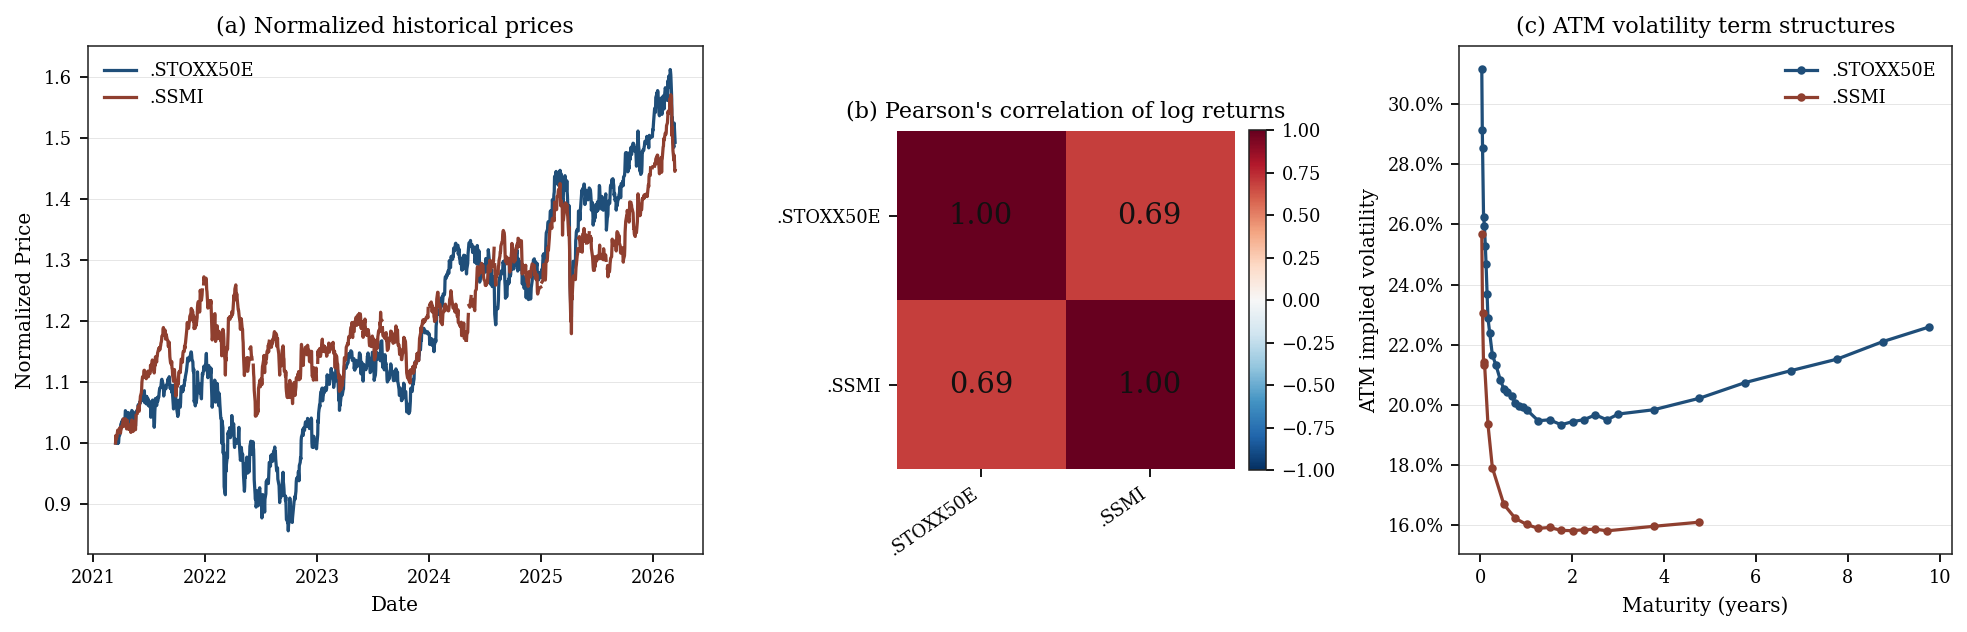

In [16]:
# FIGURE 1 — Market inputs and calibrated risk drivers.
norm_prices = normalise_prices(market_data.prices, underlyings)
corr = compute_log_return_correlation(market_data.prices, underlyings)
atm_plot = atm_curves.copy()
atm_plot["maturity_years"] = (pd.to_datetime(atm_plot["date"]) - pd.Timestamp(valuation_date)).dt.days / 365.0
atm_plot = atm_plot.loc[atm_plot["maturity_years"] >= 0.0]

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.2), gridspec_kw={"width_ratios": [1.5, 0.9, 1.2]})
ax = axes[0]
for j, asset in enumerate(underlyings):
    ax.plot(norm_prices["date"], norm_prices[asset], color=PALETTE[j], label=asset)
ax.set_title("(a) Normalized historical prices")
ax.set_ylabel("Normalized Price")
ax.set_xlabel("Date")
ax.grid(True, axis="y")
ax.legend(loc="best", handlelength=1.8)

ax = axes[1]
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("(b) Pearson's correlation of log returns")
ax.set_xticks(range(len(underlyings)), underlyings, rotation=35, ha="right")
ax.set_yticks(range(len(underlyings)), underlyings)
for i in range(len(underlyings)):
    for j in range(len(underlyings)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="#111111", fontsize=13)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2]
for j, asset in enumerate(underlyings):
    data = atm_plot.loc[atm_plot["underlying"].eq(asset)].sort_values("maturity_years")
    ax.plot(data["maturity_years"], data["atm_vol"], marker="o", markersize=2.8, color=PALETTE[j], label=asset)
ax.set_title("(c) ATM volatility term structures")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("ATM implied volatility")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, axis="y")
ax.legend(loc="best", handlelength=1.8)

fig.suptitle("", y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, "figure_1_market_inputs_risk_drivers")
plt.show()

**Figure 1 caption.** Historical and calibrated market inputs used in the classical Monte Carlo benchmark. Prices are normalized at the beginning of the sample, while the heatmap reports the empirical correlation matrix of log-returns used in the two-asset risk-neutral dynamics.

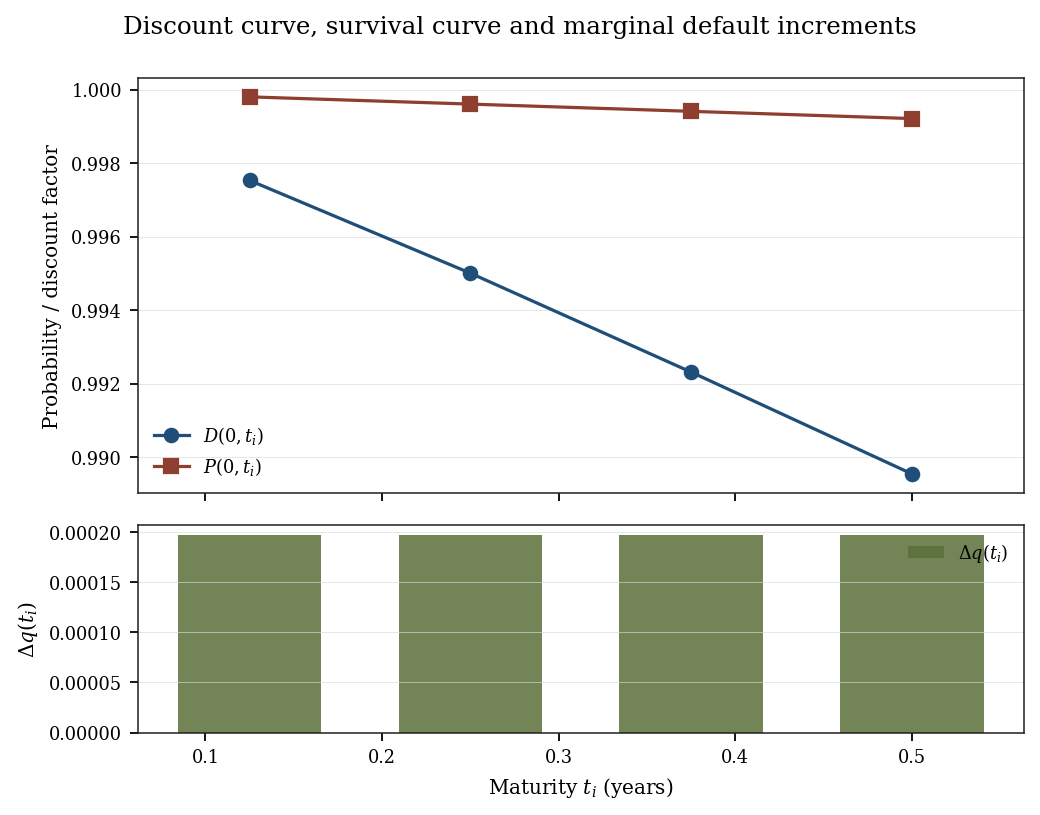

In [17]:
# FIGURE 2 — Discount curve, survival curve and default increments.
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(6.6, 5.1), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]})
ax_top.plot(t, p_t, marker="o", color=PALETTE[0], label=r"$D(0,t_i)$")
ax_top.plot(t, survival_grid, marker="s", color=PALETTE[1], label=r"$P(0,t_i)$")
ax_top.set_ylabel("Probability / discount factor")
ax_top.grid(True, axis="y")
ax_top.legend(loc="best")

bar_width = 0.65 * np.min(np.diff(np.r_[0.0, t])) if t.size > 1 else 0.05
ax_bottom.bar(t, q_t, width=bar_width, color=PALETTE[2], alpha=0.85, label=r"$\Delta q(t_i)$")
ax_bottom.set_xlabel("Maturity $t_i$ (years)")
ax_bottom.set_ylabel(r"$\Delta q(t_i)$")
ax_bottom.grid(True, axis="y")
ax_bottom.legend(loc="best")

fig.suptitle("Discount curve, survival curve and marginal default increments", y=0.99, fontsize=11)
fig.tight_layout()
save_figure(fig, "figure_2_discount_survival_default_increments")
plt.show()

**Figure 2 caption.** Discount factors, survival probabilities and marginal default increments used in the discretised CVA estimator. The default increment is computed as $\Delta q(t_i)=P(0,t_{i-1})-P(0,t_i)$.

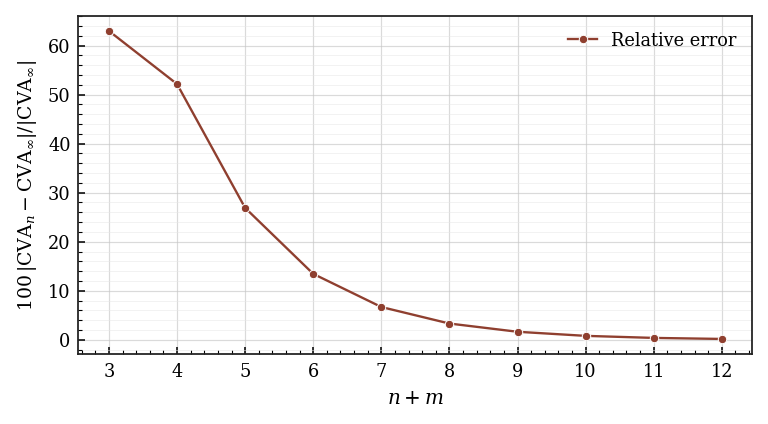

In [22]:
# FIGURE 5 — Finite-grid convergence (relative error to limit)
plot_df = finite_grid_convergence.copy()
x = plot_df["asset qubits per underlying"].to_numpy(dtype=int) + 2

pct_err = plot_df["relative error"].to_numpy(dtype=float) * 100

fig, ax = plt.subplots(figsize=(4.7, 2.55))

ax.plot(
    x,
    pct_err,
    marker="o",
    markersize=3.8,
    linewidth=1.05,
    color=PALETTE[1],
    markeredgecolor="white",
    markeredgewidth=0.45,
    label="Relative error",
)
ax.set_xlabel(r"$n + m$")

ax.set_ylabel(r"$100\,|\mathrm{CVA}_n-\mathrm{CVA}_{\infty}|/|\mathrm{CVA}_{\infty}|$", fontsize=8.5)

ax.set_yscale("linear")
ax.set_xticks(x)
ax.minorticks_on()
ax.grid(True, axis="both", which="major", color="0.78", linewidth=0.55)
ax.grid(True, axis="y", which="minor", color="0.90", linewidth=0.35)
ax.tick_params(axis="both", which="major", direction="in", length=3.0, width=0.7, labelsize=8)
ax.tick_params(axis="both", which="minor", direction="in", length=1.8, width=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=1.6)

fig.tight_layout(pad=0.35)
save_figure(fig, "figure_5_finite_grid_convergence_percentage")
plt.show()

**Figure 5 caption.** Finite-grid CVA convergence towards the limiting-grid benchmark $\mathrm{CVA}_{\infty}$. The horizontal axis reports $n+m$, with $n$ asset-grid qubits per underlying and $m=2$ time-register qubits. The rightmost benchmark point with $n=10$ corresponds to $N=2^{10+10}$ joint asset-grid cells. The vertical axis reports the relative error $100\,|\mathrm{CVA}(n)-\mathrm{CVA}_{\infty}|/|\mathrm{CVA}_{\infty}|$ in percent.

## 10. Optional Appendix Figures

These diagnostics are generated only from available or recomputed benchmark quantities.

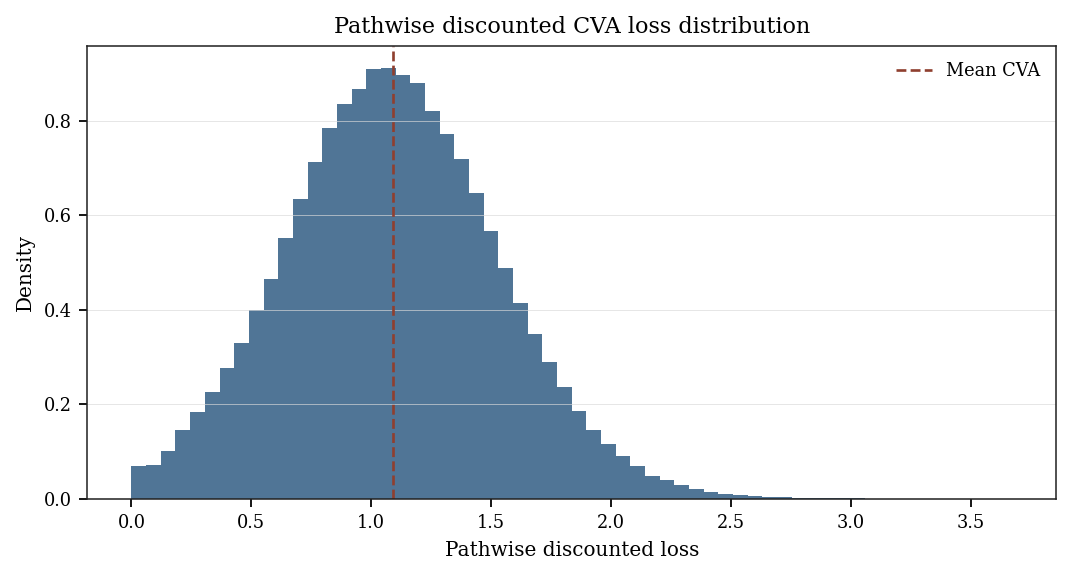

In [19]:
# Appendix Figure A1 — Histogram of pathwise discounted losses.
fig, ax = plt.subplots(figsize=(6.8, 3.7))
ax.hist(pathwise_discounted_losses, bins=60, color=PALETTE[0], alpha=0.78, density=True)
ax.axvline(pathwise_discounted_losses.mean(), color=PALETTE[1], linestyle="--", linewidth=1.2, label="Mean CVA")
ax.set_xlabel("Pathwise discounted loss")
ax.set_ylabel("Density")
ax.grid(True, axis="y")
ax.legend(loc="best")
ax.set_title("Pathwise discounted CVA loss distribution")
fig.tight_layout()
save_figure(fig, "appendix_figure_a1_pathwise_discounted_losses")
plt.show()

# 3D diagnostics for the classical benchmark

The following surfaces are **not additional model assumptions**. They are visual diagnostics of the finite time-market grid already constructed for the classical benchmark.

- \(V^+(t,S_1,S_2)\) shows the geometry of positive exposure across the two selected market factors.
- \(P(S_1,S_2\mid t)\) shows where the simulated risk-neutral probability mass lies on the finite grid.
- The local CVA surface combines exposure, conditional probability, discounting and marginal default probability:
  \[
  \mathrm{local\_cva}_{j_1,j_2}(t_i)
  =
  (1-R)D(0,t_i)\Delta q(t_i)P_{i,j_1,j_2}V^+_{i,j_1,j_2}.
  \]

The comparison across \(M=2,4,8,16,50\) uses \(M\) as the **number of monitoring dates in this diagnostic**, not the number of time qubits. This is distinct from the project configuration parameter `m_time`, where the quantum time-register size may imply \(2^{m_{\mathrm{time}}}\) monitoring states. The dense \(M=50\) grid acts as a visual reference; coarser grids show what is retained or lost under temporal discretisation.

# Continuous-to-grid discretisation diagnostic

The continuous Monte Carlo model produces samples in a continuous two-dimensional price space. The quantum CVA circuit, however, uses a finite-dimensional state-preparation register, so the continuous price domain is truncated and partitioned into bins. Each simulated scenario is assigned to a Cartesian price bin, and the empirical bin frequencies define the finite-grid probability law encoded in the state-preparation circuit.

This diagnostic visualizes that projection step. It is not a new modelling assumption: it inspects the discretisation already used by the finite market grid in the `6q_instance` benchmark.


MC scenario source: recomputed benchmark fine-time simulation and interpolated to monitoring dates
Selected t*: 0.25 years
t* index: 1
EE(t*): 2282.24084853
Delta q(t*): 0.000197048709259
CVA contribution at t*: 0.261767371865
Share of total CVA at t*: 50.162961%
Paths inside truncated domain: 199960 / 200000
Retained mass before renormalisation: 0.99980000
Probability heatmap sum after renormalisation: 1
Max absolute difference vs stored tensor slice: 0.000643625371619


NameError: name 'LABEL_FS' is not defined

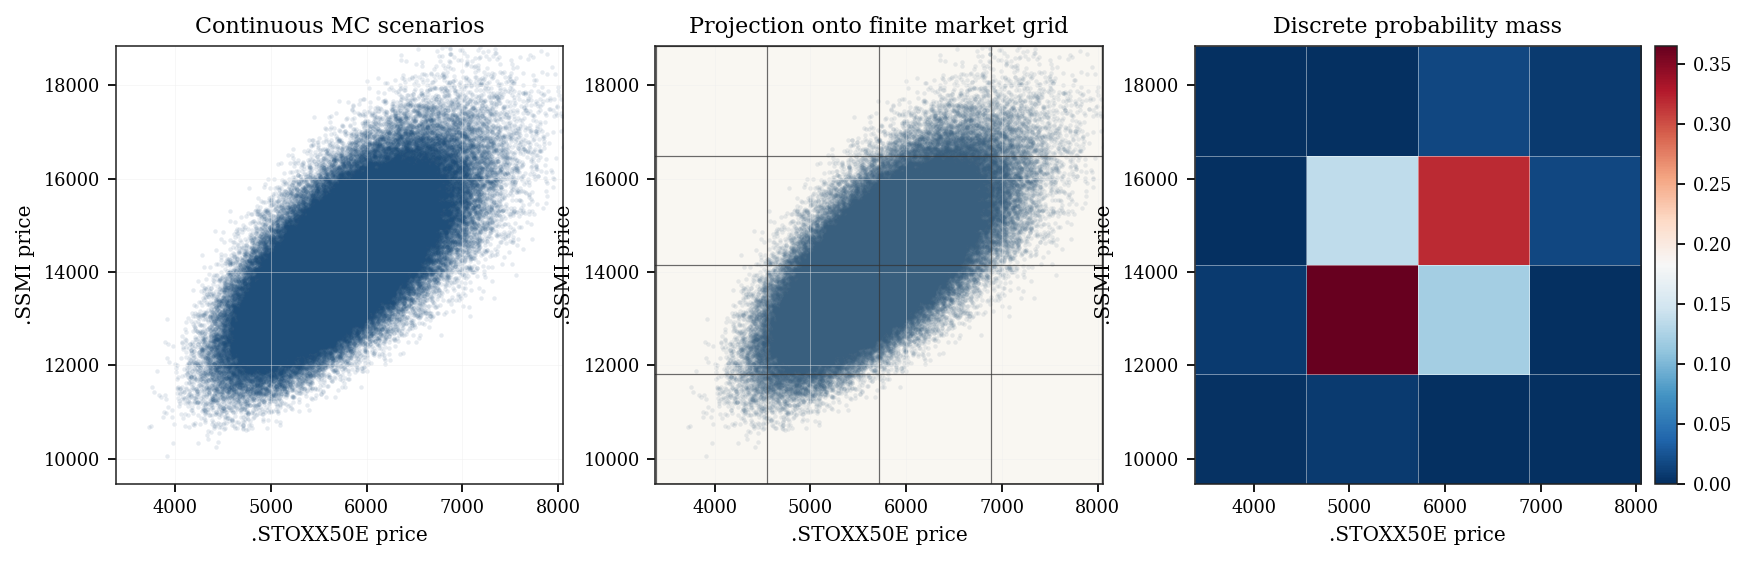

In [20]:

# Continuous-to-grid discretisation diagnostic.
from matplotlib.patches import Rectangle

DISCRETISATION_FIGURE_DIR = FIGURE_DIR / "discretisation"
DISCRETISATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

T_STAR_MODE = "max_cva_contribution"  # options: "max_cva_contribution", "middle", "final", "manual"
MANUAL_T_INDEX = None
N_BINS_CASES = [2, 4, 8, 16]
PROB_TOL = 1e-10
SCATTER_MAX_POINTS = 250000
RANDOM_VIS_SEED = 20260519


def save_discretisation_figure(fig: mpl.figure.Figure, stem: str) -> list[Path]:
    paths: list[Path] = []
    for ext in ("pdf", "svg", "png"):
        path = DISCRETISATION_FIGURE_DIR / f"{stem}.{ext}"
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path)
        paths.append(path)
    saved_figures.extend(paths)
    return paths


def save_table_exact(df: pd.DataFrame, stem: str, *, index: bool = False, float_format: str = "%.6g") -> list[Path]:
    paths: list[Path] = []
    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    tex_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=index)
    tex_path.write_text(df.to_latex(index=index, escape=False, float_format=float_format), encoding="utf-8")
    paths.extend([csv_path, tex_path])
    saved_tables.extend(paths)
    return paths


def get_selected_underlyings_from_instance(instance_dir: Path) -> list[str]:
    if "CONFIG" in globals() and isinstance(CONFIG, Mapping):
        assets = CONFIG.get("assets", [])
        found = [str(asset["symbol"]) for asset in assets if isinstance(asset, Mapping) and "symbol" in asset]
        if found:
            if len(found) != 2:
                raise ValueError(f"Expected exactly 2 selected underlyings for the 6q instance; found {found}.")
            return found

    candidates: list[tuple[Path, list[str]]] = []
    for path in Path(instance_dir).rglob("*.json"):
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue
        assets = payload.get("assets", []) if isinstance(payload, Mapping) else []
        symbols = [str(asset.get("symbol")) for asset in assets if isinstance(asset, Mapping) and asset.get("symbol")]
        if symbols:
            candidates.append((path, symbols))
    if not candidates:
        raise RuntimeError(f"Could not discover selected underlyings from {instance_dir}.")
    selected = sorted(candidates, key=lambda item: (len(item[1]) == 2, item[0].stat().st_mtime), reverse=True)[0][1]
    if len(selected) != 2:
        raise ValueError(f"Expected exactly 2 selected underlyings for the 6q instance; found {selected}.")
    return selected


def _paths_tensor_from_array(arr: Any, *, n_times: int, underlyings: Sequence[str], source: str) -> np.ndarray:
    values = np.asarray(arr, dtype=float)
    discovered = {"source": source, "shape": values.shape}
    if values.ndim != 3:
        raise ValueError(f"MC path artifact must be 3D. Discovered {discovered}.")
    n_assets = len(underlyings)
    if values.shape[2] == n_assets and values.shape[1] == n_times:
        return values
    if values.shape[2] == n_assets and values.shape[0] == n_times:
        return np.transpose(values, (1, 0, 2))
    raise ValueError(
        "Ambiguous MC path tensor shape. Expected (n_paths, n_times, n_assets) "
        f"or (n_times, n_paths, n_assets). Discovered {discovered}, n_times={n_times}, n_assets={n_assets}."
    )


def _paths_tensor_from_dict(payload: Mapping[str, Any], *, n_times: int, underlyings: Sequence[str], source: str) -> np.ndarray:
    arrays = []
    shapes = {}
    for asset in underlyings:
        if asset not in payload:
            raise ValueError(f"Dict MC path artifact from {source} is missing selected underlying {asset!r}.")
        arr = np.asarray(payload[asset], dtype=float)
        shapes[asset] = arr.shape
        if arr.ndim != 2:
            raise ValueError(f"Dict MC paths for {asset!r} must be 2D. Discovered shapes: {shapes}.")
        if arr.shape[1] == n_times:
            arrays.append(arr)
        elif arr.shape[0] == n_times:
            arrays.append(arr.T)
        else:
            raise ValueError(f"Cannot align dict MC paths for {asset!r}. Discovered shapes: {shapes}, n_times={n_times}.")
    return np.stack(arrays, axis=2)


def _paths_tensor_from_dataframe(df: pd.DataFrame, *, n_times: int, underlyings: Sequence[str], source: str) -> np.ndarray:
    if isinstance(df.columns, pd.MultiIndex):
        arrays = []
        for asset in underlyings:
            matching = [col for col in df.columns if asset in map(str, col)]
            if len(matching) != n_times:
                raise ValueError(f"DataFrame MC paths from {source} has ambiguous MultiIndex columns for {asset!r}: {matching}.")
            arrays.append(df.loc[:, matching].to_numpy(dtype=float))
        return np.stack(arrays, axis=2)

    arrays = []
    shapes = {}
    for asset in underlyings:
        cols = [col for col in df.columns if asset in str(col)]
        shapes[asset] = len(cols)
        if len(cols) != n_times:
            raise ValueError(
                f"DataFrame MC paths from {source} must have exactly {n_times} columns containing {asset!r}; "
                f"discovered {shapes}."
            )
        arrays.append(df.loc[:, cols].to_numpy(dtype=float))
    return np.stack(arrays, axis=2)


def _states_on_output_grid_local(S_by_time: np.ndarray, t_input: Sequence[float], t_output: Sequence[float]) -> np.ndarray:
    S_by_time = np.asarray(S_by_time, dtype=float)
    t_input = np.asarray(t_input, dtype=float).reshape(-1)
    t_output = np.asarray(t_output, dtype=float).reshape(-1)
    if S_by_time.ndim != 3 or S_by_time.shape[1] != t_input.size:
        raise ValueError(f"Cannot interpolate path tensor with shape {S_by_time.shape} on time grid {t_input.shape}.")
    if not np.all(np.diff(t_input) > 0.0) or not np.all(np.diff(t_output) > 0.0):
        raise ValueError("Input and output time grids must be strictly increasing.")
    out = []
    tol = 1e-12
    for tau in t_output:
        j = int(np.searchsorted(t_input, tau, side="left"))
        if j < t_input.size and np.isclose(t_input[j], tau, atol=tol, rtol=0.0):
            out.append(S_by_time[:, j, :])
        elif j > 0 and np.isclose(t_input[j - 1], tau, atol=tol, rtol=0.0):
            out.append(S_by_time[:, j - 1, :])
        elif 0 < j < t_input.size:
            alpha = (float(tau) - float(t_input[j - 1])) / (float(t_input[j]) - float(t_input[j - 1]))
            out.append((1.0 - alpha) * S_by_time[:, j - 1, :] + alpha * S_by_time[:, j, :])
        else:
            raise ValueError(f"Output time {tau} lies outside the simulated time grid.")
    return np.stack(out, axis=1)


def load_or_recompute_mc_paths_at_monitoring_dates(instance_dir: Path, market_data_dir: Path) -> tuple[np.ndarray, str]:
    selected = get_selected_underlyings_from_instance(instance_dir)
    n_times = int(np.asarray(t).size)

    artifact_keys = [
        "S_by_time", "s_by_time", "S_paths", "paths", "mc_paths", "S_by_time_fine", "s_by_time_fine",
        "underlying_paths", "simulated_paths", "price_paths",
    ]
    for path in sorted(Path(instance_dir).rglob("*.npz"), key=lambda p: ("benchmark" not in str(p).lower(), len(str(p)))):
        try:
            data = np.load(path, allow_pickle=True)
        except Exception:
            continue
        for key in artifact_keys:
            if key not in data.files:
                continue
            raw = data[key]
            try:
                if raw.shape == () and isinstance(raw.item(), Mapping):
                    tensor = _paths_tensor_from_dict(raw.item(), n_times=n_times, underlyings=selected, source=f"{path}:{key}")
                else:
                    tensor = _paths_tensor_from_array(raw, n_times=n_times, underlyings=selected, source=f"{path}:{key}")
                return tensor, f"saved artifact {rel_to_project(path)}:{key}"
            except Exception as exc:
                print(f"[info] Skipping candidate MC path artifact {rel_to_project(path)}:{key}: {exc}")

    if "build_continuous_engine_and_paths" not in globals():
        raise RuntimeError(
            "Continuous MC scenario values at monitoring dates are not stored, and the notebook helper "
            "build_continuous_engine_and_paths is unavailable to reproduce the benchmark simulation."
        )

    # Reproduce the benchmark branch that generated the saved small-grid tensor: draw the coarse
    # random normals first, then the fine-time normals, using the same RNG stream.
    selected = list(selected)
    d = len(selected)
    maturity_max = float(scalar_from_npz(benchmark, "T", required=False, default=max(float(inst["maturity_years"]) for inst in CONFIG.get("instruments", []))))
    fine_time_grid_size = int(classical_cfg.get("fine_time_grid_size", 50))
    t_fine = np.linspace(0.0, maturity_max, fine_time_grid_size, dtype=float)[1:]
    n_paths_cfg = int(classical_cfg.get("n_paths", 100_000))
    rng = np.random.default_rng(int(classical_cfg.get("seed", 105)))
    _ = rng.standard_normal(size=(n_paths_cfg, n_times, d))
    z_fine = rng.standard_normal(size=(n_paths_cfg, t_fine.size, d))

    flat_override = market_cfg.get("flat_interest_rate_override")
    if flat_override is None:
        r_used = float(-np.log(market_data.discount_factor(1.0)))
    else:
        r_used = float(flat_override)
    atm_vol_curves = market_data.get_atm_vol_curves(underlyings=selected)
    sigma_grid = build_piecewise_sigma_grid(atm_vol_curves=atm_vol_curves, underlyings=selected, sim_times=t)
    s0_list = market_data.get_spot_vector(selected)
    rho = market_data.get_log_return_correlation(selected)
    mu_list = [r_used - dividend_yields[symbol] for symbol in selected]
    s_by_time_fine = simulate_multi_asset_gbm(
        S0=s0_list,
        mu=mu_list,
        sigma=sigma_grid,
        sigma_times=t,
        rho=rho,
        t=t_fine,
        Z=z_fine,
        antithetic=bool(classical_cfg.get("antithetic", True)),
        moment_match=bool(classical_cfg.get("moment_match", True)),
        replications=int(classical_cfg.get("replications", 1)),
        replication_seed=int(classical_cfg.get("replication_seed", 12345)),
        pathwise=True,
    )
    tensor = _states_on_output_grid_local(s_by_time_fine, t_fine, t)
    return tensor, "recomputed benchmark fine-time simulation and interpolated to monitoring dates"


def get_representative_t_index(grid_case: Mapping[str, Any], mode: str = "max_cva_contribution") -> int:
    mode = str(mode).lower()
    times = np.asarray(grid_case["t"], dtype=float).reshape(-1)
    if mode == "max_cva_contribution":
        contribution = np.asarray(grid_case["cva_contribution"], dtype=float).reshape(-1)
        if contribution.shape != times.shape:
            raise ValueError(f"CVA contribution shape {contribution.shape} does not align with t {times.shape}.")
        return int(np.nanargmax(contribution))
    if mode == "middle":
        return int(len(times) // 2)
    if mode == "final":
        return int(len(times) - 1)
    if mode == "manual":
        if MANUAL_T_INDEX is None:
            raise ValueError("T_STAR_MODE='manual' requires MANUAL_T_INDEX to be set.")
        idx = int(MANUAL_T_INDEX)
        if idx < 0 or idx >= len(times):
            raise IndexError(f"MANUAL_T_INDEX={idx} is outside [0, {len(times)-1}].")
        return idx
    raise ValueError(f"Unknown T_STAR_MODE: {mode!r}.")


def get_asset_bin_edges(instance_dir: Path, underlyings: Sequence[str], t_index: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    if "edges_list" not in benchmark.files:
        raise FileNotFoundError(
            "The benchmark artifact is missing 'edges_list', so the finite market grid used by the quantum circuit cannot be recovered."
        )
    edges_obj = np.asarray(benchmark["edges_list"], dtype=object)
    edges = tuple(np.asarray(edge, dtype=float).reshape(-1) for edge in edges_obj)
    if len(edges) != len(underlyings):
        raise ValueError(f"edges_list length {len(edges)} does not match selected underlyings {underlyings}.")
    for asset, edge in zip(underlyings, edges):
        if edge.ndim != 1 or edge.size < 2 or not np.all(np.diff(edge) > 0.0):
            raise ValueError(f"Bin edges for {asset!r} are not strictly increasing: {edge}.")
    return edges[0], edges[1]


def assign_paths_to_2d_bins(S1_values: Sequence[float], S2_values: Sequence[float], S1_edges: Sequence[float], S2_edges: Sequence[float]) -> tuple[np.ndarray, np.ndarray, float]:
    x = np.asarray(S1_values, dtype=float).reshape(-1)
    y = np.asarray(S2_values, dtype=float).reshape(-1)
    e1 = np.asarray(S1_edges, dtype=float).reshape(-1)
    e2 = np.asarray(S2_edges, dtype=float).reshape(-1)
    if x.shape != y.shape:
        raise ValueError(f"S1 and S2 path arrays must align. Got {x.shape} and {y.shape}.")
    if not np.all(np.diff(e1) > 0.0) or not np.all(np.diff(e2) > 0.0):
        raise ValueError("All bin edges must be strictly increasing.")
    finite = np.isfinite(x) & np.isfinite(y)
    inside = finite & (x >= e1[0]) & (x <= e1[-1]) & (y >= e2[0]) & (y <= e2[-1])
    counts, _, _ = np.histogram2d(x[finite], y[finite], bins=[e1, e2])
    retained_mass = float(inside.sum() / finite.sum()) if finite.sum() else 0.0
    return counts.astype(float), inside, retained_mass


def compute_conditional_probability_heatmap(
    S1_values: Sequence[float],
    S2_values: Sequence[float],
    S1_edges: Sequence[float],
    S2_edges: Sequence[float],
    *,
    tolerance: float = PROB_TOL,
) -> tuple[np.ndarray, np.ndarray, float]:
    counts, inside, retained_mass = assign_paths_to_2d_bins(S1_values, S2_values, S1_edges, S2_edges)
    total_inside = float(counts.sum())
    if total_inside <= 0.0:
        raise ValueError("No Monte Carlo scenarios fall inside the truncated representable domain.")
    prob = counts / total_inside
    if np.any(prob < -tolerance):
        raise ValueError("Conditional probability heatmap contains negative entries.")
    prob = np.clip(prob, 0.0, None)
    prob = prob / float(prob.sum())
    if abs(float(prob.sum()) - 1.0) >= tolerance:
        raise ValueError(f"Conditional probability heatmap does not sum to one: {prob.sum()}.")
    return prob, inside, retained_mass


def _subsample_for_plot(x: np.ndarray, y: np.ndarray, max_points: int = SCATTER_MAX_POINTS) -> tuple[np.ndarray, np.ndarray]:
    if x.size <= max_points:
        return x, y
    rng = np.random.default_rng(RANDOM_VIS_SEED)
    idx = rng.choice(x.size, size=max_points, replace=False)
    return x[idx], y[idx]


def _cloud_limits(x: np.ndarray, y: np.ndarray, e1: np.ndarray, e2: np.ndarray) -> tuple[tuple[float, float], tuple[float, float]]:
    xlo, xhi = np.nanpercentile(x, [0.4, 99.6])
    ylo, yhi = np.nanpercentile(y, [0.4, 99.6])
    xlo = min(float(xlo), float(e1[0])); xhi = max(float(xhi), float(e1[-1]))
    ylo = min(float(ylo), float(e2[0])); yhi = max(float(yhi), float(e2[-1]))
    xpad = 0.04 * max(xhi - xlo, 1.0)
    ypad = 0.04 * max(yhi - ylo, 1.0)
    return (xlo - xpad, xhi + xpad), (ylo - ypad, yhi + ypad)


def _exact_terminal_domain_limits_from_benchmark() -> tuple[tuple[float, float], tuple[float, float]]:
    s0 = np.asarray(benchmark["S0"], dtype=float).reshape(-1)
    mu = np.asarray(benchmark["mu"], dtype=float).reshape(-1)
    sigma = np.asarray(benchmark["sigma"], dtype=float)
    times = np.asarray(benchmark["t"], dtype=float).reshape(-1)
    if s0.size < 2 or mu.size < 2 or sigma.ndim != 2 or sigma.shape[1] < 2:
        raise ValueError("Benchmark must contain S0, mu, and a two-asset sigma grid to compute exact domain limits.")
    if sigma.shape[0] != times.size:
        raise ValueError(f"Benchmark sigma rows must align with t. Got sigma={sigma.shape}, t={times.shape}.")

    dt = np.diff(np.r_[0.0, times])
    maturity = float(times[-1])
    integrated_variance = np.sum(sigma[:, :2] ** 2 * dt[:, None], axis=0)
    mean = s0[:2] * np.exp(mu[:2] * maturity)
    std = mean * np.sqrt(np.exp(integrated_variance) - 1.0)
    lower = np.maximum(mean - 3.0 * std, 0.0)
    upper = mean + 3.0 * std
    return (float(lower[0]), float(upper[0])), (float(lower[1]), float(upper[1]))


def plot_continuous_to_grid_2d(
    S1_values: Sequence[float],
    S2_values: Sequence[float],
    S1_edges: Sequence[float],
    S2_edges: Sequence[float],
    prob_heatmap: np.ndarray,
    underlyings: Sequence[str],
    t_star: float,
) -> mpl.figure.Figure:
    x = np.asarray(S1_values, dtype=float).reshape(-1)
    y = np.asarray(S2_values, dtype=float).reshape(-1)
    e1 = np.asarray(S1_edges, dtype=float).reshape(-1)
    e2 = np.asarray(S2_edges, dtype=float).reshape(-1)
    xp, yp = _subsample_for_plot(x, y)
    xlim, ylim = _exact_terminal_domain_limits_from_benchmark()

    fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.55), gridspec_kw={"width_ratios": [1.0, 1.0, 1.08]})

    for ax in axes[:2]:
        ax.scatter(xp, yp, s=4, alpha=0.11, color=PALETTE[0], linewidths=0)
        ax.set_xlabel(f"{underlyings[0]} price")
        ax.set_ylabel(f"{underlyings[1]} price")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, color="#eeeeee", linewidth=0.35, alpha=0.55)

    axes[0].set_title("Continuous MC scenarios")

    ax = axes[1]
    rect = Rectangle((e1[0], e2[0]), e1[-1] - e1[0], e2[-1] - e2[0], facecolor="#d8c9a3", edgecolor="#333333", alpha=0.14, linewidth=0.8)
    ax.add_patch(rect)
    for edge in e1:
        ax.axvline(edge, color="#333333", linewidth=0.55, alpha=0.72)
    for edge in e2:
        ax.axhline(edge, color="#333333", linewidth=0.55, alpha=0.72)
    ax.set_title("Projection onto finite market grid")

    ax = axes[2]
    vmax = float(np.nanmax(prob_heatmap)) if prob_heatmap.size else 1.0
    im = ax.imshow(
        prob_heatmap.T,
        origin="lower",
        extent=[e1[0], e1[-1], e2[0], e2[-1]],
        aspect="auto",
        cmap="RdBu_r",
        vmin=0.0,
        vmax=vmax,
    )
    ax.set_xlabel(f"{underlyings[0]} price")
    ax.set_ylabel(f"{underlyings[1]} price")
    ax.set_title("Discrete probability mass")
    for edge in e1:
        ax.axvline(edge, color="white", linewidth=0.35, alpha=0.55)
    for edge in e2:
        ax.axhline(edge, color="white", linewidth=0.35, alpha=0.55)
    cbar = fig.colorbar(im, ax=ax, fraction=0.047, pad=0.03)
    fig.text(0.08, 0.975, f"t = {t_star:.6g} years", fontsize=LABEL_FS, fontweight="bold")
    cbar.set_label("Conditional probability")

    fig.suptitle(f"Continuous-to-grid projection at t* = {t_star:.6g} years", y=1.03, fontsize=11)
    fig.tight_layout()
    return fig


def plot_probability_heatmap_grid_resolution_comparison(
    S1_values: Sequence[float],
    S2_values: Sequence[float],
    S1_edges: Sequence[float],
    S2_edges: Sequence[float],
    n_bins_cases: Sequence[int],
    underlyings: Sequence[str],
) -> tuple[mpl.figure.Figure, dict[int, np.ndarray]]:
    e1_base = np.asarray(S1_edges, dtype=float).reshape(-1)
    e2_base = np.asarray(S2_edges, dtype=float).reshape(-1)
    heatmaps: dict[int, np.ndarray] = {}
    edges_by_n: dict[int, tuple[np.ndarray, np.ndarray]] = {}
    vmax = 0.0
    for n_bins_case in n_bins_cases:
        e1 = np.linspace(e1_base[0], e1_base[-1], int(n_bins_case) + 1)
        e2 = np.linspace(e2_base[0], e2_base[-1], int(n_bins_case) + 1)
        prob, _, _ = compute_conditional_probability_heatmap(S1_values, S2_values, e1, e2)
        heatmaps[int(n_bins_case)] = prob
        edges_by_n[int(n_bins_case)] = (e1, e2)
        vmax = max(vmax, float(prob.max()))

    fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.3), sharex=True, sharey=True)
    last_im = None
    for ax, n_bins_case in zip(axes.flat, n_bins_cases):
        e1, e2 = edges_by_n[int(n_bins_case)]
        prob = heatmaps[int(n_bins_case)]
        last_im = ax.imshow(prob.T, origin="lower", extent=[e1[0], e1[-1], e2[0], e2[-1]], aspect="auto", cmap="RdBu_r", vmin=0.0, vmax=vmax)
        ax.set_title(f"N = {int(n_bins_case)}")
        ax.grid(False)
    for ax in axes[:, 0]:
        ax.set_ylabel(f"{underlyings[1]} price")
    for ax in axes[-1, :]:
        ax.set_xlabel(f"{underlyings[0]} price")
    if last_im is not None:
        fig.text(0.08, 0.975, f"t = {t_star:.6g} years", fontsize=LABEL_FS, fontweight="bold")
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.038, pad=0.025)
        cbar.set_label("Conditional probability")
    fig.suptitle("Probability heatmaps by asset-grid resolution", y=0.995, fontsize=11)
    fig.tight_layout(rect=[0, 0, 0.95, 0.97])
    return fig, heatmaps


def plot_continuous_to_grid_1d(
    values: Sequence[float],
    edges: Sequence[float],
    underlying: str,
    t_star: float,
) -> mpl.figure.Figure:
    x = np.asarray(values, dtype=float).reshape(-1)
    e = np.asarray(edges, dtype=float).reshape(-1)
    counts, _ = np.histogram(x[np.isfinite(x)], bins=e)
    total = float(counts.sum())
    if total <= 0.0:
        raise ValueError(f"No paths for {underlying!r} fall inside the finite grid domain.")
    prob = counts / total
    centers = 0.5 * (e[:-1] + e[1:])
    widths = np.diff(e)

    fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.2), gridspec_kw={"width_ratios": [1.0, 1.0, 0.95]})
    axes[0].hist(x, bins=70, density=True, color=PALETTE[0], alpha=0.72)
    axes[0].set_title("Continuous histogram")
    axes[0].set_xlabel(f"{underlying} price")
    axes[0].set_ylabel("Density")
    axes[0].grid(True, axis="y", color="#eeeeee", linewidth=0.35)

    axes[1].hist(x, bins=70, density=True, color=PALETTE[0], alpha=0.50)
    for edge in e:
        axes[1].axvline(edge, color="#333333", linewidth=0.65, alpha=0.72)
    axes[1].axvspan(e[0], e[-1], color="#d8c9a3", alpha=0.13)
    axes[1].set_title("Quantum bin edges")
    axes[1].set_xlabel(f"{underlying} price")
    axes[1].grid(True, axis="y", color="#eeeeee", linewidth=0.35)

    axes[2].bar(centers, prob, width=0.86 * widths, align="center", color=PALETTE[2], alpha=0.82, edgecolor="#222222", linewidth=0.45)
    axes[2].set_title("Discrete bin probabilities")
    axes[2].set_xlabel(f"{underlying} price")
    axes[2].set_ylabel("Probability")
    axes[2].grid(True, axis="y", color="#eeeeee", linewidth=0.35)
    fig.text(0.08, 0.975, f"t = {t_star:.6g} years", fontsize=LABEL_FS, fontweight="bold")
    fig.tight_layout()
    return fig


def compute_probability_entropy(prob_matrix: np.ndarray) -> float:
    p = np.asarray(prob_matrix, dtype=float).reshape(-1)
    if np.any(p < -PROB_TOL):
        raise ValueError("Probability matrix contains negative values.")
    p = p[p > 0.0]
    return float(-np.sum(p * np.log(p)))


def count_cells_for_probability_mass(prob_matrix: np.ndarray, threshold: float) -> int:
    p = np.sort(np.asarray(prob_matrix, dtype=float).reshape(-1))[::-1]
    if not 0.0 < float(threshold) <= 1.0:
        raise ValueError("threshold must lie in (0, 1].")
    if p.size == 0:
        return 0
    return int(np.searchsorted(np.cumsum(p), float(threshold), side="left") + 1)


selected_underlyings = get_selected_underlyings_from_instance(INSTANCE_DIR)
if list(selected_underlyings) != list(underlyings):
    raise ValueError(f"Notebook underlyings {underlyings} differ from rediscovered instance underlyings {selected_underlyings}.")
if len(selected_underlyings) != 2:
    raise ValueError(f"The diagnostic requires exactly two selected underlyings; found {selected_underlyings}.")

mc_paths_monitoring, mc_paths_source = load_or_recompute_mc_paths_at_monitoring_dates(INSTANCE_DIR, MARKET_DATA_DIR)
if mc_paths_monitoring.shape[1] != t.size or mc_paths_monitoring.shape[2] != 2:
    raise ValueError(f"MC paths must have shape (n_paths, {t.size}, 2); got {mc_paths_monitoring.shape} from {mc_paths_source}.")

s1_edges, s2_edges = get_asset_bin_edges(INSTANCE_DIR, selected_underlyings, None)
asset_n_bins = (len(s1_edges) - 1, len(s2_edges) - 1)
if tuple(asset_n_bins) != tuple(np.asarray(benchmark["n_bins"], dtype=int).reshape(-1)):
    print(f"[warning] Edge-derived bins {asset_n_bins} differ from benchmark n_bins {benchmark['n_bins']}.")

grid_case = {
    "t": t,
    "ee": ee_tabulated,
    "p_t": p_t,
    "q_t": q_t,
    "cva_contribution": (1.0 - recovery_rate) * p_t * q_t * ee_tabulated,
}
t_star_idx = get_representative_t_index(grid_case, T_STAR_MODE)
t_star = float(t[t_star_idx])
ee_tstar = float(ee_tabulated[t_star_idx])
dq_tstar = float(q_t[t_star_idx])
cva_contribution_tstar = float(grid_case["cva_contribution"][t_star_idx])
total_cva_contribution = float(np.sum(grid_case["cva_contribution"]))
share_tstar = cva_contribution_tstar / total_cva_contribution if total_cva_contribution != 0.0 else np.nan

S_tstar = mc_paths_monitoring[:, t_star_idx, :]
prob_heatmap, inside_domain, retained_mass = compute_conditional_probability_heatmap(
    S_tstar[:, 0],
    S_tstar[:, 1],
    s1_edges,
    s2_edges,
)
probability_sum = float(prob_heatmap.sum())
assert abs(probability_sum - 1.0) < PROB_TOL

stored_tensor_slice = P_joint_t[t_star_idx].reshape(asset_n_bins, order="C")
stored_tensor_slice = stored_tensor_slice / float(stored_tensor_slice.sum())
max_abs_diff_vs_stored = float(np.max(np.abs(prob_heatmap - stored_tensor_slice)))

print(f"MC scenario source: {mc_paths_source}")
print(f"Selected t*: {t_star:.12g} years")
print(f"t* index: {t_star_idx}")
print(f"EE(t*): {ee_tstar:.12g}")
print(f"Delta q(t*): {dq_tstar:.12g}")
print(f"CVA contribution at t*: {cva_contribution_tstar:.12g}")
print(f"Share of total CVA at t*: {share_tstar:.6%}")
print(f"Paths inside truncated domain: {int(inside_domain.sum())} / {mc_paths_monitoring.shape[0]}")
print(f"Retained mass before renormalisation: {retained_mass:.8f}")
print(f"Probability heatmap sum after renormalisation: {probability_sum:.12g}")
print(f"Max absolute difference vs stored tensor slice: {max_abs_diff_vs_stored:.12g}")

fig = plot_continuous_to_grid_2d(S_tstar[:, 0], S_tstar[:, 1], s1_edges, s2_edges, prob_heatmap, selected_underlyings, t_star)
main_discretisation_paths = save_discretisation_figure(fig, "continuous_to_grid_2d_tstar")
plt.show()
print(
    "Caption: Projection from continuous Monte Carlo scenarios to the finite market grid at the representative "
    "monitoring date t*. Each simulated scenario is assigned to a Cartesian price bin. After truncation and "
    "renormalisation, the empirical bin frequencies define the discrete probability mass used by the quantum "
    "state-preparation register."
)

fig, resolution_heatmaps = plot_probability_heatmap_grid_resolution_comparison(
    S_tstar[:, 0],
    S_tstar[:, 1],
    s1_edges,
    s2_edges,
    N_BINS_CASES,
    selected_underlyings,
)
resolution_paths = save_discretisation_figure(fig, "probability_heatmaps_by_asset_grid_resolution")
plt.show()
print(
    "Caption: Discrete probability heatmaps obtained by projecting the same continuous Monte Carlo scenarios onto "
    "increasingly fine asset grids. The comparison illustrates the information retained or lost as the continuous "
    "distribution is represented by a finite number of price bins."
)

one_d_paths: list[Path] = []
for asset, values, edges in zip(selected_underlyings, [S_tstar[:, 0], S_tstar[:, 1]], [s1_edges, s2_edges]):
    safe_asset = re.sub(r"[^A-Za-z0-9_.-]+", "_", asset).strip("_")
    fig = plot_continuous_to_grid_1d(values, edges, asset, t_star)
    one_d_paths.extend(save_discretisation_figure(fig, f"continuous_to_grid_1d_{safe_asset}"))
    plt.show()
print(
    "Caption: Univariate projection from the continuous Monte Carlo distribution of the underlying price to its "
    "finite-bin representation at t*. The bin probabilities correspond to the marginal discrete law induced by the market grid."
)

summary_df = pd.DataFrame([{
    "selected t*": t_star,
    "t* index": int(t_star_idx),
    "underlying 1": selected_underlyings[0],
    "underlying 2": selected_underlyings[1],
    "number of MC paths": int(mc_paths_monitoring.shape[0]),
    "number of paths inside truncated domain": int(inside_domain.sum()),
    "retained mass before renormalisation": retained_mass,
    "number of bins S1": int(asset_n_bins[0]),
    "number of bins S2": int(asset_n_bins[1]),
    "total grid cells": int(prob_heatmap.size),
    "probability sum after renormalisation": probability_sum,
    "max cell probability": float(prob_heatmap.max()),
    "entropy of discrete distribution": compute_probability_entropy(prob_heatmap),
    "number of cells explaining 50% probability mass": count_cells_for_probability_mass(prob_heatmap, 0.50),
    "number of cells explaining 90% probability mass": count_cells_for_probability_mass(prob_heatmap, 0.90),
    "max absolute difference vs stored tensor slice": max_abs_diff_vs_stored,
}])
summary_paths = save_table_exact(summary_df, "discretisation_diagnostic_summary", index=False)
display(summary_df)

heatmap_df = pd.DataFrame(
    prob_heatmap,
    index=[f"{selected_underlyings[0]} bin {i}" for i in range(prob_heatmap.shape[0])],
    columns=[f"{selected_underlyings[1]} bin {j}" for j in range(prob_heatmap.shape[1])],
)
heatmap_paths = save_table_exact(heatmap_df, "discrete_probability_heatmap_tstar", index=True)
display(heatmap_df)

discretisation_figure_paths = main_discretisation_paths + resolution_paths + one_d_paths
discretisation_table_paths = summary_paths + heatmap_paths

print("Final discretisation inventory")
print(f"Selected underlyings: {selected_underlyings}")
print(f"Selected t*: {t_star:.12g} years (index {t_star_idx})")
print(f"Retained mass: {retained_mass:.8f}")
print(f"Probability sum: {probability_sum:.12g}")
print("Saved discretisation figure paths:")
for path in discretisation_figure_paths:
    print(f"- {rel_to_project(path)}")
print("Saved table paths:")
for path in discretisation_table_paths:
    print(f"- {rel_to_project(path)}")


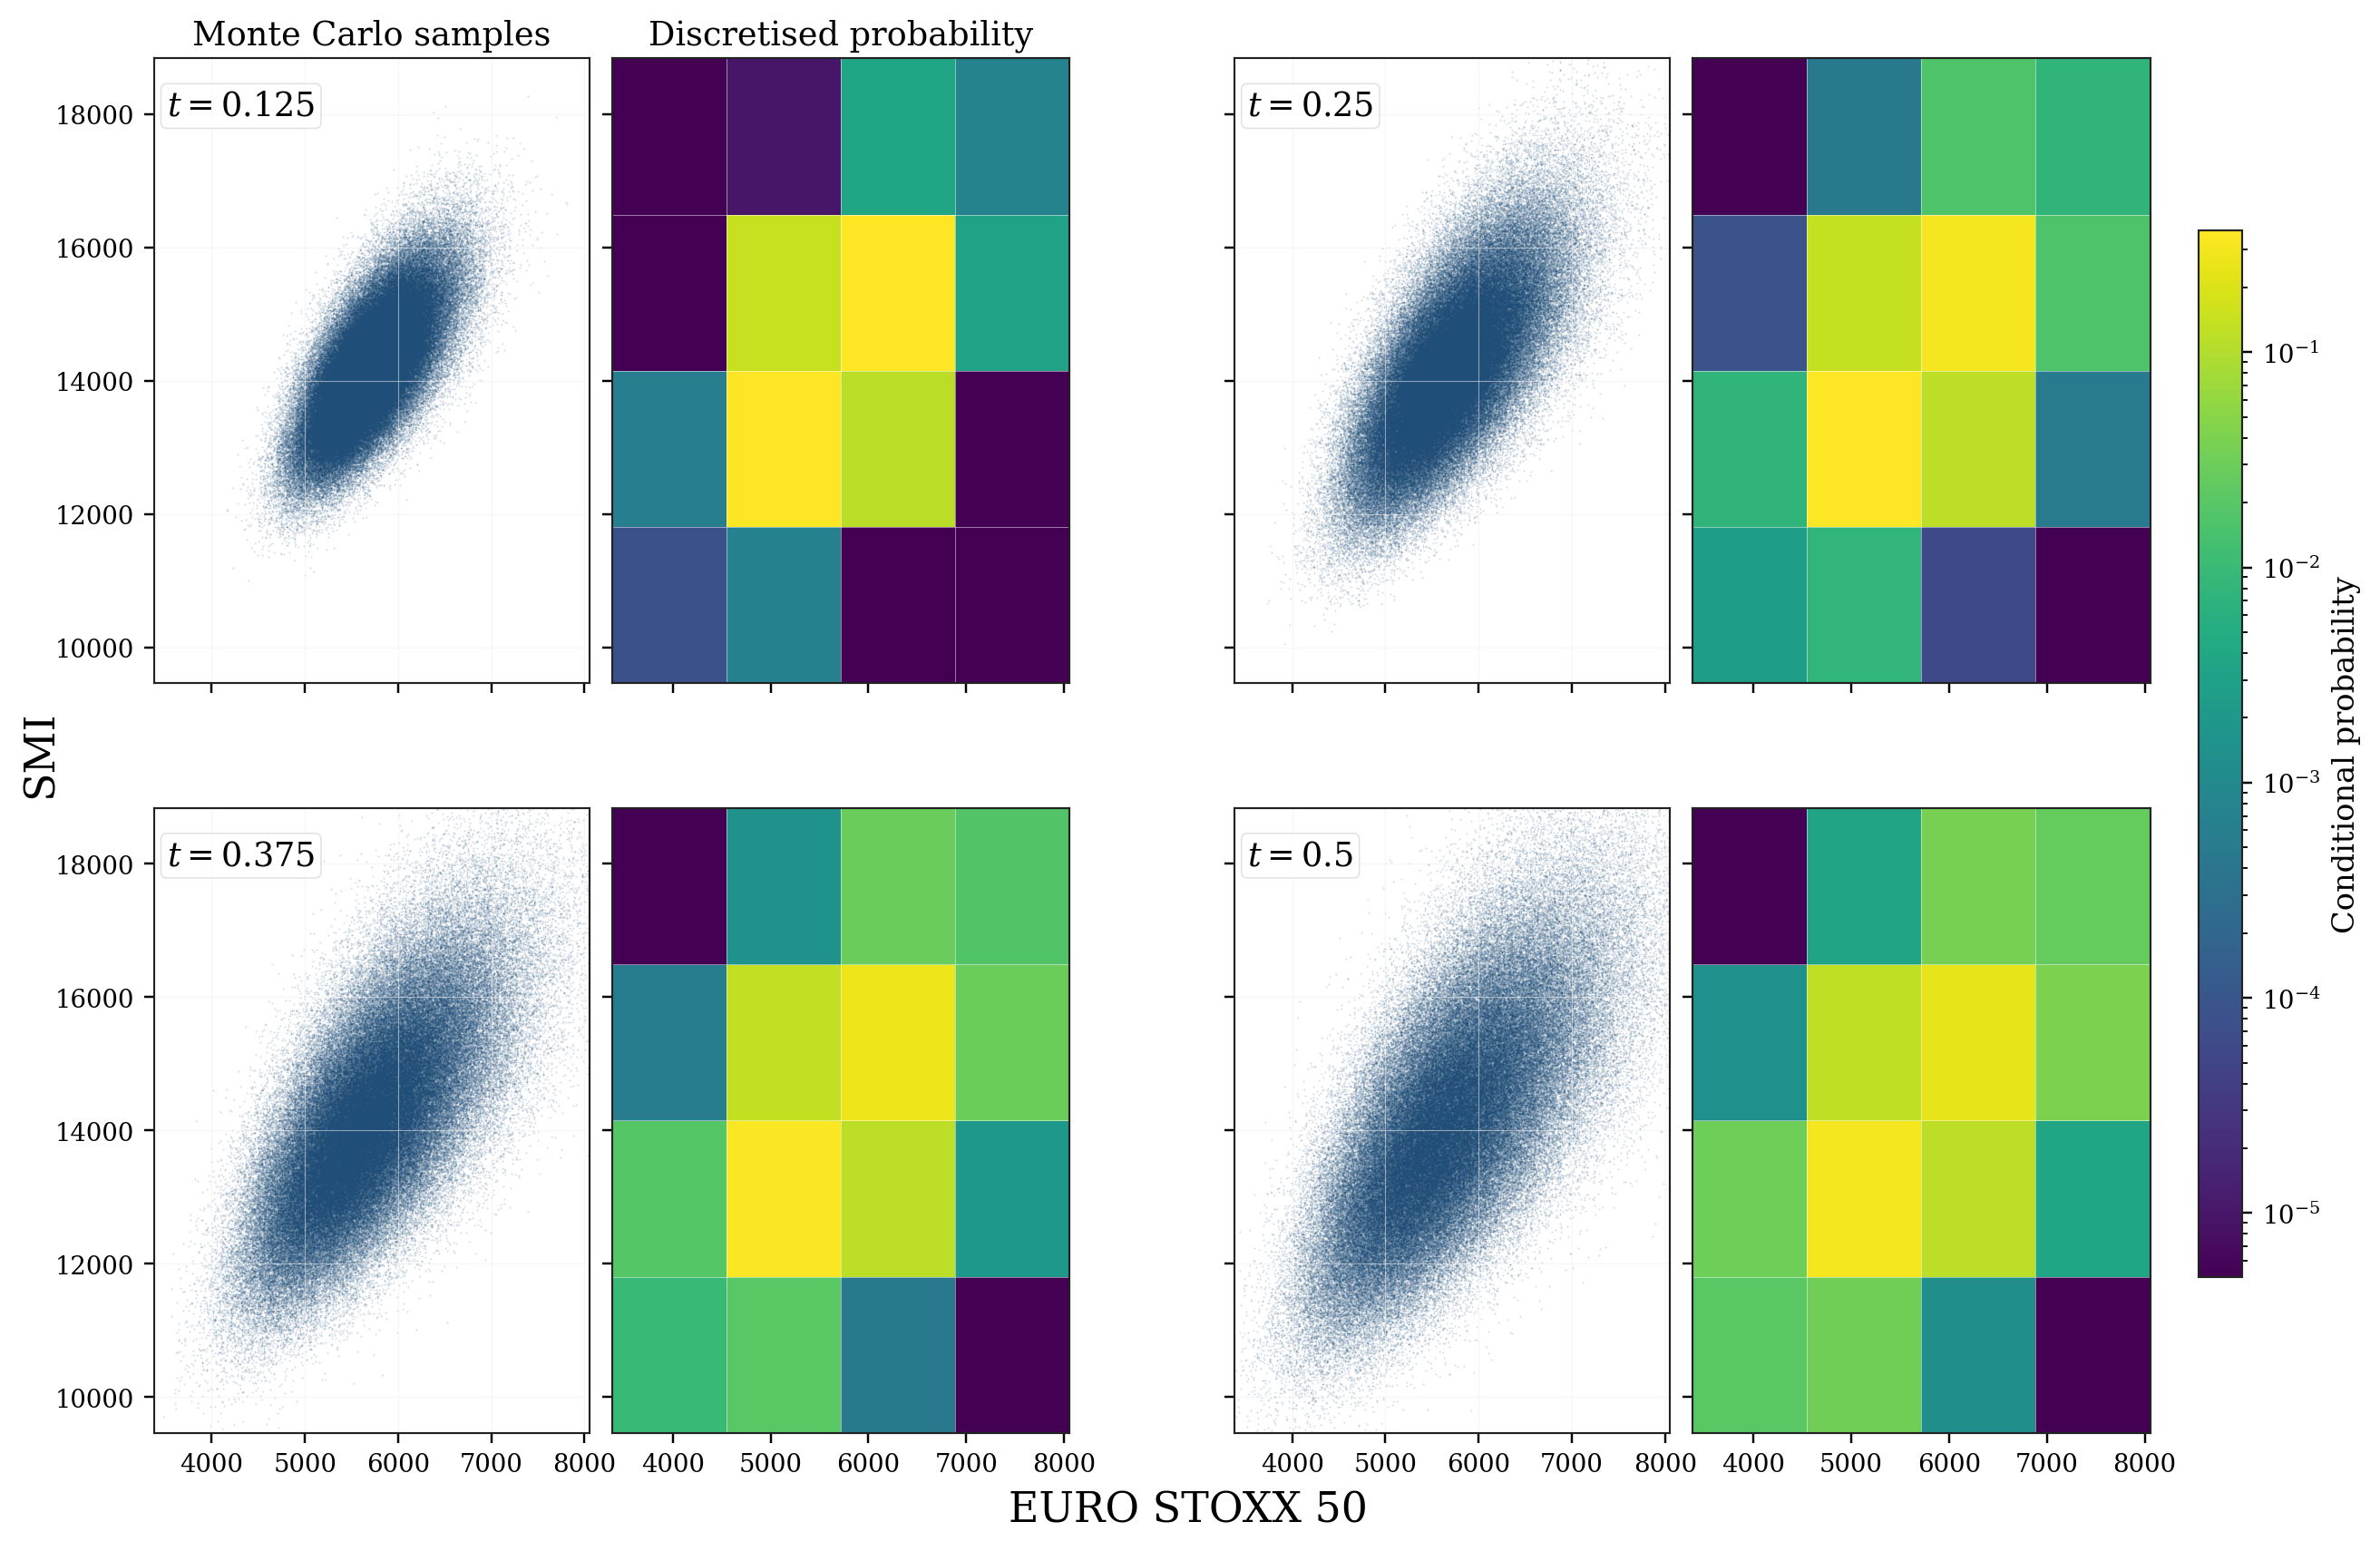

Included continuous-to-grid projection for t=0.125 (index 0, retained mass=1.00000000, inside=200000)
Included continuous-to-grid projection for t=0.25 (index 1, retained mass=0.99980000, inside=199960)
Included continuous-to-grid projection for t=0.375 (index 2, retained mass=0.99750500, inside=199501)
Included continuous-to-grid projection for t=0.5 (index 3, retained mass=0.99187000, inside=198374)
Updated combined continuous-to-grid figure:
- toys\multi_asset_demos\figures\classical_benchmark\discretisation\continuous_to_grid_2d_all_times_2x2.pdf
- toys\multi_asset_demos\figures\classical_benchmark\discretisation\continuous_to_grid_2d_all_times_2x2.svg
- toys\multi_asset_demos\figures\classical_benchmark\discretisation\continuous_to_grid_2d_all_times_2x2.png


In [ ]:
# Combined continuous-to-grid discretisation diagnostic.
# 2x2 time layout, with each time block containing:
# left = MC cloud, right = discretised conditional probability.

from matplotlib.colors import LogNorm

LABEL_FS = 15
TICK_FS = 9
CBAR_FS = 11
TIME_FS = 12
COL_FS = 12


def _safe_time_token(value: float) -> str:
    token = f"{value:.6g}"
    token = re.sub(r"[^A-Za-z0-9_.-]+", "_", token)
    return token.replace(".", "p").strip("_")


def plot_continuous_to_grid_2d_panel(
    panels: Sequence[dict],
    S1_edges: Sequence[float],
    S2_edges: Sequence[float],
    underlyings: Sequence[str],
) -> mpl.figure.Figure:
    e1 = np.asarray(S1_edges, dtype=float).reshape(-1)
    e2 = np.asarray(S2_edges, dtype=float).reshape(-1)

    xlim, ylim = _exact_terminal_domain_limits_from_benchmark()

    all_probs = np.concatenate(
        [
            np.asarray(panel["prob_heatmap"], dtype=float).ravel()
            for panel in panels
            if np.asarray(panel["prob_heatmap"]).size
        ]
    )
    positive_probs = all_probs[all_probs > 0.0]

    if positive_probs.size:
        vmin = float(np.quantile(positive_probs, 0.01))
        vmin = max(vmin, float(np.min(positive_probs)))
        vmax = float(np.quantile(positive_probs, 0.995))
        vmax = max(vmax, vmin * 1.01)
        norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)
    else:
        norm = None

    fig = plt.figure(figsize=(12.2, 8.2), dpi=220)
    outer = fig.add_gridspec(
        2,
        2,
        left=0.075,
        right=0.895,
        bottom=0.085,
        top=0.925,
        wspace=0.18,
        hspace=0.20,
    )

    image = None

    for panel_idx, panel in enumerate(panels):
        row = panel_idx // 2
        col = panel_idx % 2

        inner = outer[row, col].subgridspec(
            1,
            2,
            width_ratios=[1.0, 1.05],
            wspace=0.05,
        )

        ax_cloud = fig.add_subplot(inner[0, 0])
        ax_grid = fig.add_subplot(inner[0, 1], sharex=ax_cloud, sharey=ax_cloud)

        S_t = np.asarray(panel["S_t"], dtype=float)
        prob_heatmap = np.asarray(panel["prob_heatmap"], dtype=float)
        t_value = float(panel["t_value"])

        x = S_t[:, 0].reshape(-1)
        y = S_t[:, 1].reshape(-1)
        xp, yp = _subsample_for_plot(x, y)

        ax_cloud.scatter(
            xp,
            yp,
            s=1.6,
            alpha=0.20,
            marker=".",
            color=PALETTE[0],
            linewidths=0,
            rasterized=True,
        )
        ax_cloud.text(
            0.03,
            0.95,
            f"$t = {t_value:.4g}$",
            transform=ax_cloud.transAxes,
            fontsize=TIME_FS,
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="#dddddd",
                alpha=0.88,
            ),
        )
        ax_cloud.grid(True, color="#eeeeee", linewidth=0.35, alpha=0.55)

        image = ax_grid.imshow(
            prob_heatmap.T,
            origin="lower",
            extent=[e1[0], e1[-1], e2[0], e2[-1]],
            aspect="auto",
            cmap="viridis",
            norm=norm,
        )

        for edge in e1:
            ax_grid.axvline(edge, color="white", linewidth=0.28, alpha=0.55)
        for edge in e2:
            ax_grid.axhline(edge, color="white", linewidth=0.28, alpha=0.55)

        for ax in (ax_cloud, ax_grid):
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.tick_params(axis="both", labelsize=TICK_FS)

        ax_grid.tick_params(labelleft=False)

        if row == 0:
            ax_cloud.tick_params(labelbottom=False)
            ax_grid.tick_params(labelbottom=False)

        if col == 1:
            ax_cloud.tick_params(labelleft=False)

        if row == 0 and col == 0:
            ax_cloud.set_title("Monte Carlo samples", fontsize=COL_FS, pad=5)
            ax_grid.set_title("Discretised probability", fontsize=COL_FS, pad=5)

    fig.supxlabel(f"EURO STOXX 50", fontsize=LABEL_FS, y=0.025)
    fig.supylabel(f"SMI", fontsize=LABEL_FS, x=0.020)

    cbar_ax = fig.add_axes([0.915, 0.18, 0.018, 0.64])
    cbar = fig.colorbar(image, cax=cbar_ax)
    cbar.set_label("Conditional probability", fontsize=CBAR_FS)
    cbar.ax.tick_params(labelsize=TICK_FS)

    return fig


desired_times = [0.125, 0.25, 0.375, 0.5]
t_arr = np.asarray(t, dtype=float)

extra_t_indices = []
for dt in desired_times:
    matches = np.where(np.isclose(t_arr, dt, atol=1e-12, rtol=0.0))[0]
    if matches.size == 0:
        idx = int(np.argmin(np.abs(t_arr - dt)))
    else:
        idx = int(matches[0])
    if idx not in extra_t_indices:
        extra_t_indices.append(idx)

panels = []
for idx in extra_t_indices[:4]:
    t_value = float(t[idx])
    S_t = mc_paths_monitoring[:, idx, :]
    prob_heatmap_t, inside_domain_t, retained_mass_t = compute_conditional_probability_heatmap(
        S_t[:, 0],
        S_t[:, 1],
        s1_edges,
        s2_edges,
    )

    panels.append(
        {
            "idx": idx,
            "t_value": t_value,
            "S_t": S_t,
            "prob_heatmap": prob_heatmap_t,
            "inside_domain": inside_domain_t,
            "retained_mass": retained_mass_t,
        }
    )

fig = plot_continuous_to_grid_2d_panel(
    panels,
    s1_edges,
    s2_edges,
    selected_underlyings,
)

extra_continuous_to_grid_paths = save_discretisation_figure(
    fig,
    "continuous_to_grid_2d_all_times_2x2",
)

plt.show()

for panel in panels:
    print(
        f"Included continuous-to-grid projection for t={panel['t_value']:.6g} "
        f"(index {panel['idx']}, retained mass={panel['retained_mass']:.8f}, "
        f"inside={int(panel['inside_domain'].sum())})"
    )

print("Updated combined continuous-to-grid figure:")
for path in extra_continuous_to_grid_paths:
    print(f"- {rel_to_project(path)}")

**Continuous-to-grid diagnostic captions.** The 2D figure shows the continuous Monte Carlo scenario cloud, the same cloud with the quantum finite-market-grid overlay, and the resulting conditional probability heatmap at the selected representative monitoring date. The grid-resolution comparison projects the same scenarios onto increasingly fine rectangular grids. The 1D companion figures show the marginal projection for each selected underlying.
